### 1. Montar en Google Drive y Definir la Ruta del Dataset

Primero, montaremos Google Drive para que Colab pueda acceder a los archivos. Nos aseguramos que el dataset de Roboflow esté en una ubicación accesible de Drive.

In [ ]:
from google.colab import drive
import os
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Montar Google Drive
drive.mount('/content/drive')

# --- RUTA DE TU DATASET ---
# Actualiza esta ruta a la ubicación de tu carpeta de dataset de Roboflow en Google Drive.
# Por ejemplo: '/content/drive/MyDrive/my_roboflow_dataset/yolov8'
dataset_path = '/content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8'

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"La ruta del dataset no existe: {dataset_path}\nPor favor, actualiza 'dataset_path' a la ubicación correcta en tu Google Drive.")
else:
    print(f"Ruta del dataset encontrada: {dataset_path}")

# Rutas a los directorios de imágenes y etiquetas
# Asumimos una estructura como: dataset_path/train/images, dataset_path/train/labels, etc.
# y un data.yaml en la raíz del dataset_path o en la carpeta de la versión del dataset (ej. /content/drive/MyDrive/my_roboflow_dataset/data.yaml)

# Intenta encontrar el archivo data.yaml
data_yaml_path = os.path.join(dataset_path, 'data.yaml')
if not os.path.exists(data_yaml_path):
    # Si no está en la raíz, podría estar un nivel más arriba si el usuario apuntó a la carpeta 'yolov8'
    parent_dir = os.path.dirname(dataset_path)
    if os.path.exists(os.path.join(parent_dir, 'data.yaml')):
        data_yaml_path = os.path.join(parent_dir, 'data.yaml')
    else:
        print(f"Advertencia: No se encontró 'data.yaml' en {dataset_path} ni en su directorio padre. Las clases se mostrarán como IDs numéricos.")
        data_yaml = None
else:
    with open(data_yaml_path, 'r') as f:
        data_yaml = yaml.safe_load(f)
    print(f"'data.yaml' cargado desde: {data_yaml_path}")

class_names = data_yaml['names'] if data_yaml and 'names' in data_yaml else None
print("Nombres de las clases: ", class_names)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ruta del dataset encontrada: /content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8
'data.yaml' cargado desde: /content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8/data.yaml
Nombres de las clases:  ['defecating-dog', 'dog']


### 2. Procesar Anotaciones YOLO y Crear DataFrame

Este paso leerá todos los archivos `.txt` de las anotaciones YOLO en los directorios de `labels` (train, valid, test) y creará un DataFrame de pandas con la información de las cajas delimitadoras. Esto facilitará el análisis.


Además, este paso verifica si hay valores nulos en el DataFrame de anotaciones y si todas las imágenes tienen archivos de etiquetas correspondientes. También se revisará si hay archivos de anotaciones vacíos.

In [ ]:
annotations = []
label_dirs = []

# Buscar directorios de etiquetas (ej. train/labels, valid/labels, test/labels)
for root, dirs, files in os.walk(dataset_path):
    if 'labels' in dirs:
        label_dirs.append(os.path.join(root, 'labels'))

if not label_dirs:
    print("No se encontraron directorios 'labels' en la ruta del dataset. Asegúrate de que el dataset esté en el formato YOLOv8 esperado.")
else:
    print(f"Directorios de etiquetas encontrados: {label_dirs}")

image_files = set()
label_files = set()

for label_dir in label_dirs:
    for filename in os.listdir(label_dir):
        if filename.endswith('.txt'):
            label_files.add(os.path.join(label_dir, filename))
            image_id = os.path.splitext(filename)[0]

            # Buscar la imagen correspondiente (asumiendo que está en una carpeta 'images' hermana)
            image_parent_dir = os.path.dirname(label_dir)
            potential_image_path_jpg = os.path.join(image_parent_dir, 'images', f'{image_id}.jpg')
            potential_image_path_png = os.path.join(image_parent_dir, 'images', f'{image_id}.png')

            if os.path.exists(potential_image_path_jpg):
                image_files.add(potential_image_path_jpg)
            elif os.path.exists(potential_image_path_png):
                image_files.add(potential_image_path_png)
            else:
                # Si no se encuentra, la imagen real no es estrictamente necesaria para la EDA de anotaciones
                pass

            with open(os.path.join(label_dir, filename), 'r') as f:
                lines = f.readlines()
                if not lines: # Check for empty annotation files
                    annotations.append({
                        'image_filename': image_id,
                        'class_id': None,
                        'x_center': None, 'y_center': None,
                        'width': None, 'height': None,
                        'has_annotations': False
                    })
                    continue

                for line in lines:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        try:
                            class_id, x_center, y_center, width, height = map(float, parts)
                            annotations.append({
                                'image_filename': image_id,
                                'class_id': int(class_id),
                                'x_center': x_center,
                                'y_center': y_center,
                                'width': width,
                                'height': height,
                                'has_annotations': True
                            })
                        except ValueError:
                            print(f"Advertencia: Línea malformada en {filename}: {line.strip()}")
                    else:
                        print(f"Advertencia: Línea con formato incorrecto en {filename}: {line.strip()}")

df_annotations = pd.DataFrame(annotations)

print("### 7. Revisión de la Calidad de los Datos\n")

if not df_annotations.empty:
    quality_report = {}

    # 1. Valores Faltantes (Missing Values)
    missing_values = df_annotations.isnull().sum()
    missing_values_count = missing_values[missing_values > 0]
    quality_report['Valores Faltantes'] = missing_values_count.to_dict()
    print("**Valores Faltantes por Columna:**")
    if not missing_values_count.empty:
        display(missing_values_count.to_frame(name='Count'))
        print("Interpretación: Columnas como 'class_id', 'x_center', etc., con valores faltantes indican anotaciones incompletas o archivos de etiquetas vacíos para algunas imágenes. Esto puede llevar a que esas instancias no se usen en el entrenamiento o causen errores si no se manejan.")
    else:
        print("No se encontraron valores faltantes en el DataFrame de anotaciones.")
    print("\n" + "-" * 50 + "\n")

    # 2. Valores Duplicados
    duplicate_rows_count = df_annotations.duplicated().sum()
    quality_report['Valores Duplicados'] = duplicate_rows_count
    print(f"**Número de Filas Duplicadas Completas:** {duplicate_rows_count}")
    if duplicate_rows_count > 0:
        print("Interpretación: Las filas duplicadas exactas pueden inflar artificialmente la cuenta de anotaciones y sesgar el análisis. Es recomendable eliminarlas si representan un error de ingestión de datos.")
    else:
        print("No se encontraron filas duplicadas completas en el DataFrame de anotaciones.")
    print("\n" + "-" * 50 + "\n")

    # 3. Valores Inconsistentes / Formatos Incorrectos (rango esperado)
    # Verificación de coordenadas y dimensiones normalizadas [0, 1]
    columns_to_check_range = ['x_center', 'y_center', 'width', 'height']
    inconsistent_range_counts = {}
    for col in columns_to_check_range:
        if col in df_annotations.columns:
            # Filtrar NaNs antes de la verificación de rango
            out_of_range = df_annotations[col].dropna()[~df_annotations[col].dropna().between(0, 1)].count()
            if out_of_range > 0:
                inconsistent_range_counts[col] = out_of_range

    # Verificación de class_id dentro del rango de class_names
    if class_names and 'class_id' in df_annotations.columns:
        invalid_class_ids = df_annotations['class_id'].dropna().apply(lambda x: x < 0 or x >= len(class_names)).sum()
        if invalid_class_ids > 0:
            inconsistent_range_counts['class_id_invalid_range'] = invalid_class_ids

    quality_report['Valores Inconsistentes (Rango)'] = inconsistent_range_counts
    print("**Valores Inconsistentes (Fuera del rango esperado [0,1] para coordenadas/dimensiones, o ID de clase inválido):**")
    if inconsistent_range_counts:
        for col, count in inconsistent_range_counts.items():
            print(f"- Columna '{col}': {count} valores fuera de rango.")
        print("Interpretación: Valores fuera del rango [0,1] en coordenadas o dimensiones, o IDs de clase incorrectos, son errores críticos en las anotaciones YOLO. Deben ser corregidos, ya que el modelo espera estos rangos.")
    else:
        print("No se encontraron valores inconsistentes fuera del rango esperado en coordenadas, dimensiones o IDs de clase.")
    print("\n" + "-" * 50 + "\n")

    # 4. Registros Anómalos (Outliers cuantificados con IQR)
    outlier_counts = {}
    numerical_cols_for_outliers = ['width', 'height', 'area', 'aspect_ratio']

    for col in numerical_cols_for_outliers:
        if col in df_annotations.columns:
            Q1 = df_annotations[col].quantile(0.25)
            Q3 = df_annotations[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Filtrar NaNs antes de contar outliers
            col_data = df_annotations[col].dropna()
            outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)].count()
            if outliers > 0:
                outlier_counts[col] = outliers

    quality_report['Registros Anómalos (Outliers IQR)'] = outlier_counts
    print("**Registros Anómalos (Outliers detectados por IQR 1.5x):**")
    if outlier_counts:
        for col, count in outlier_counts.items():
            print(f"- Columna '{col}': {count} outliers detectados (valores muy pequeños o muy grandes).")
        print("Interpretación: Un alto número de outliers puede indicar variabilidad extrema en los objetos (ej. objetos muy pequeños o muy grandes, o relaciones de aspecto inusuales) o errores en el etiquetado. Pueden afectar la robustez del modelo si no se manejan o comprenden.")
    else:
        print("No se detectaron outliers significativos mediante el método IQR en las dimensiones de las bounding boxes.")
    print("\n" + "-" * 50 + "\n")

    print("**Resumen General de Calidad de Datos:**")
    print("\nEl siguiente resumen proporciona una visión rápida de los problemas identificados. Se deben priorizar los problemas críticos (como valores faltantes e inconsistencias de rango) antes de los análisis más profundos.\n")
    for key, value in quality_report.items():
        if isinstance(value, dict) and value:
            print(f"- {key}: {len(value)} columnas con problemas ({', '.join(value.keys())})")
        elif isinstance(value, int) and value > 0:
            print(f"- {key}: {value} ocurrencias")
        else:
            print(f"- {key}: Sin problemas detectados")

else:
    print("No hay datos de anotaciones para realizar la revisión de calidad.")

if df_annotations.empty:
    print("No se encontraron anotaciones válidas para analizar. Asegúrate de que los archivos de etiquetas existan y estén correctamente formateados.")
else:
    # Calcular área y relación de aspecto de las bounding boxes
    df_annotations['area'] = df_annotations['width'] * df_annotations['height']
    df_annotations['aspect_ratio'] = df_annotations['width'] / df_annotations['height']

    # Reemplazar infinitos en aspect_ratio (si height es 0) con NaN o un valor sensato
    df_annotations['aspect_ratio'] = df_annotations['aspect_ratio'].replace([np.inf, -np.inf], np.nan)
    # Eliminar filas donde width o height sean 0, ya que causan problemas en area y aspect_ratio
    df_annotations = df_annotations[~((df_annotations['width'] == 0) | (df_annotations['height'] == 0))].copy()

    display(df_annotations.head())
    print(f"Total de anotaciones procesadas: {len(df_annotations)}")

    print("Conteo de valores nulos por columna en el DataFrame de anotaciones:")
    display(df_annotations.isnull().sum())

    # Conteo de imágenes sin anotaciones (archivos de etiquetas vacíos o faltantes)
    images_without_annotations = df_annotations[df_annotations['has_annotations'] == False]['image_filename'].nunique()
    print(f"\nNúmero de imágenes con archivos de anotaciones vacíos o sin anotaciones: {images_without_annotations}")

    # Verificar si hay imágenes sin archivos de etiquetas en absoluto (requiere comparar con el directorio de imágenes)
    # Esto es más complejo ya que 'image_files' es solo un conjunto de las imágenes que *tienen* etiquetas.
    # Para una verificación completa, necesitaríamos escanear todos los directorios de imágenes.

    # Ejemplo de cómo obtener todas las imágenes si fuera necesario:
    all_image_paths = []
    for root, dirs, files in os.walk(dataset_path):
        if 'images' in dirs:
            for img_file in os.listdir(os.path.join(root, 'images')):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    all_image_paths.append(os.path.join(root, 'images', img_file))

    all_image_filenames = {os.path.splitext(os.path.basename(path))[0] for path in all_image_paths}
    annotated_image_filenames = set(df_annotations['image_filename'].unique())

    images_with_no_label_file = all_image_filenames - annotated_image_filenames
    print(f"Número de imágenes sin un archivo de anotación correspondiente: {len(images_with_no_label_file)}")
    if images_with_no_label_file:
        print("Primeros 5 nombres de imágenes sin archivo de anotación:", list(images_with_no_label_file)[:5])


Directorios de etiquetas encontrados: ['/content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8/test/labels', '/content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8/train/labels', '/content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8/valid/labels']
### 7. Revisión de la Calidad de los Datos

**Valores Faltantes por Columna:**
No se encontraron valores faltantes en el DataFrame de anotaciones.

--------------------------------------------------

**Número de Filas Duplicadas Completas:** 0
No se encontraron filas duplicadas completas en el DataFrame de anotaciones.

--------------------------------------------------

**Valores Inconsistentes (Fuera del rango esperado [0,1] para coordenadas/dimensiones, o ID de clase inválido):**
No se encontraron valores inconsistentes fuera del rango esperado en coordenadas, di

,image_filename,class_id,x_center,y_center,width,height,has_annotations,area,aspect_ratio
0,1616164550_1-p-sobaka-khatiko-sobaka-foto-1_jp...,1,0.564844,0.514062,0.617188,0.856250,True,0.528467,0.720803
1,youtube-89_jpg.rf.7efc7255482c36b37a3f0272fe7e...,1,0.695693,0.685667,0.505495,0.628667,True,0.317788,0.804075
2,Welsh-Corgi35_jpg.rf.056c0d2c038571612495f3c1a...,1,0.485156,0.536719,0.848437,0.704688,True,0.597883,1.203991
3,Welsh-Corgi35_jpg.rf.056c0d2c038571612495f3c1a...,1,0.641406,0.394531,0.539062,0.423438,True,0.228259,1.273063
4,-28-_jpg.rf.38a5f9d47b60512b9ba4a62f3e6d947a,1,0.546094,0.351562,0.653125,0.703125,True,0.459229,0.928889


Total de anotaciones procesadas: 1366
Conteo de valores nulos por columna en el DataFrame de anotaciones:


,0
image_filename,0
class_id,0
x_center,0
y_center,0
width,0
height,0
has_annotations,0
area,0
aspect_ratio,0



Número de imágenes con archivos de anotaciones vacíos o sin anotaciones: 0
Número de imágenes sin un archivo de anotación correspondiente: 0


### 3. Estadísticas Descriptivas

Observaremos las estadísticas clave para las dimensiones de las cajas delimitadoras (ancho, alto, área y relación de aspecto) con el ánimo de tener un mejor entendimiento del dataset.

In [ ]:
if not df_annotations.empty:
    print("### 3. Estadísticas Descriptivas (Detallado)\n")
    print("**Tabla de Estadísticas Descriptivas para Ancho, Alto, Área y Relación de Aspecto (valores relativos):**")

    # Calcular las estadísticas descriptivas
    descriptive_stats = df_annotations[['width', 'height', 'area', 'aspect_ratio']].describe()
    display(descriptive_stats)

    print("\n**Breve Interpretación de los Valores Obtenidos:**")
    print("Estas estadísticas resumen las características principales de las dimensiones de las bounding boxes en tu dataset:\n")

    for col in descriptive_stats.columns:
        mean_val = descriptive_stats.loc['mean', col]
        median_val = descriptive_stats.loc['50%', col] # Mediana es el percentil 50
        std_val = descriptive_stats.loc['std', col]
        min_val = descriptive_stats.loc['min', col]
        max_val = descriptive_stats.loc['max', col]
        q25 = descriptive_stats.loc['25%', col]
        q75 = descriptive_stats.loc['75%', col]
        iqr = q75 - q25

        print(f"- **{col.replace('_', ' ').title()}**:")
        print(f"  - **Media ({mean_val:.4f}) y Mediana ({median_val:.4f})**: Indican la tendencia central. Si son similares, la distribución es probablemente simétrica. Diferencias significativas pueden sugerir asimetría o la presencia de outliers.")
        print(f"  - **Desviación Estándar ({std_val:.4f})**: Mide la dispersión de los datos. Un valor alto indica que las dimensiones varían mucho, mientras que un valor bajo sugiere que están más agrupadas alrededor de la media.")
        print(f"  - **Mínimo ({min_val:.4f}) y Máximo ({max_val:.4f})**: Representan el rango completo de los valores. Valores extremos aquí pueden ser indicios de anotaciones erróneas o de objetos muy pequeños/grandes.")
        print(f"  - **Percentiles (25%, 50%, 75%)**: Muestran cómo se distribuyen los datos. El 25% y el 75% definen el rango intercuartílico (IQR), que contiene el 50% central de los datos. Son útiles para detectar posibles valores extremos al observar la distancia entre el mínimo/máximo y los cuartiles.\n")

    print("En general, estos valores te ayudan a entender el tamaño y la forma típica de los objetos en tu dataset, así como la variabilidad existente. Presta especial atención a los valores mínimos y máximos, y a las diferencias entre la media y la mediana para identificar posibles anomalías que podrían requerir una inspección más profunda en tus anotaciones.")
else:
    print("No hay datos de anotaciones para mostrar estadísticas descriptivas.")

### 3. Estadísticas Descriptivas (Detallado)

**Tabla de Estadísticas Descriptivas para Ancho, Alto, Área y Relación de Aspecto (valores relativos):**


,width,height,area,aspect_ratio
count,1366.000000,1366.000000,1366.000000,1366.000000
mean,0.547876,0.598621,0.351376,0.988330
std,0.215748,0.213937,0.212086,0.448730
min,0.057063,0.074453,0.005776,0.186851
25%,0.387000,0.440084,0.181124,0.692139
50%,0.551667,0.611136,0.317183,0.926053
75%,0.710036,0.768980,0.494835,1.153181
max,1.000000,1.000000,0.972539,3.237996



**Breve Interpretación de los Valores Obtenidos:**
Estas estadísticas resumen las características principales de las dimensiones de las bounding boxes en tu dataset:

- **Width**:
  - **Media (0.5479) y Mediana (0.5517)**: Indican la tendencia central. Si son similares, la distribución es probablemente simétrica. Diferencias significativas pueden sugerir asimetría o la presencia de outliers.
  - **Desviación Estándar (0.2157)**: Mide la dispersión de los datos. Un valor alto indica que las dimensiones varían mucho, mientras que un valor bajo sugiere que están más agrupadas alrededor de la media.
  - **Mínimo (0.0571) y Máximo (1.0000)**: Representan el rango completo de los valores. Valores extremos aquí pueden ser indicios de anotaciones erróneas o de objetos muy pequeños/grandes.
  - **Percentiles (25%, 50%, 75%)**: Muestran cómo se distribuyen los datos. El 25% y el 75% definen el rango intercuartílico (IQR), que contiene el 50% central de los datos. Son útiles para detectar posibl

### 4. Análisis de Distribuciones

Este paso se enfoca en comprender la forma de las distribuciones de las dimensiones clave de las bounding boxes (ancho, alto, área, relación de aspecto). Analizaremos si son normales, sesgadas o multimodales, dónde se concentran los valores y la visibilidad de los valores extremos.

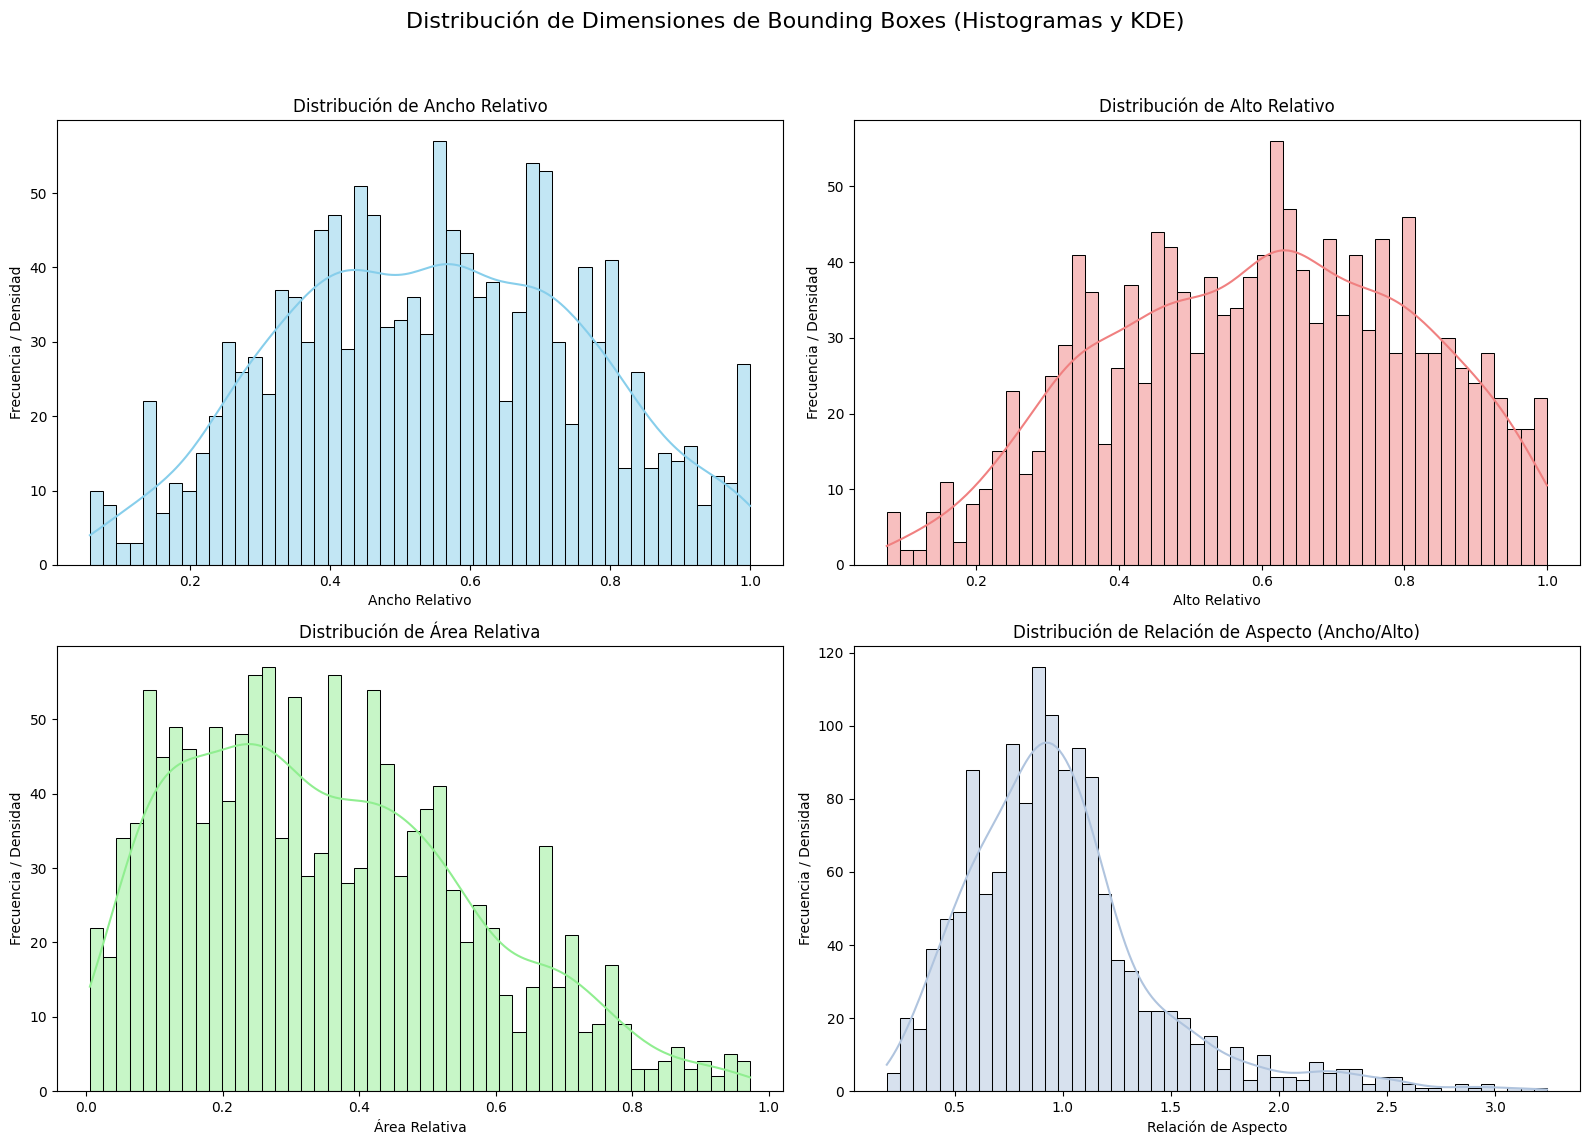


**Interpretación de los Patrones Observados en las Distribuciones:**

- **Ancho Relativo (width):**
  - **Forma:** La distribución parece ser bimodal o ligeramente multimodal, con picos alrededor de 0.3-0.4 y 0.7-0.8. Esto sugiere que existen dos grupos principales de objetos en términos de su ancho relativo. Puede haber objetos pequeños/medianos y objetos grandes en tu dataset.
  - **Concentración:** La mayoría de los valores se concentran en los rangos de los picos mencionados, mostrando menos densidad en los anchos intermedios. Hay una concentración notable en el rango medio-alto.
  - **Valores Extremos:** Hay una cola hacia valores muy bajos (objetos muy estrechos) y algunos objetos que ocupan casi todo el ancho (valores cercanos a 1), pero la distribución general no muestra una asimetría extrema.

- **Alto Relativo (height):**
  - **Forma:** Similar al ancho, esta distribución también muestra características bimodales, con concentraciones alrededor de 0.4-0.5 y 0.7-0.8. Esto podr

In [ ]:
if not df_annotations.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Distribución de Dimensiones de Bounding Boxes (Histogramas y KDE)', fontsize=16)

    # Histograma y KDE para Ancho
    sns.histplot(df_annotations['width'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Distribución de Ancho Relativo')
    axes[0, 0].set_xlabel('Ancho Relativo')
    axes[0, 0].set_ylabel('Frecuencia / Densidad')

    # Histograma y KDE para Alto
    sns.histplot(df_annotations['height'], bins=50, kde=True, ax=axes[0, 1], color='lightcoral')
    axes[0, 1].set_title('Distribución de Alto Relativo')
    axes[0, 1].set_xlabel('Alto Relativo')
    axes[0, 1].set_ylabel('Frecuencia / Densidad')

    # Histograma y KDE para Área
    sns.histplot(df_annotations['area'], bins=50, kde=True, ax=axes[1, 0], color='lightgreen')
    axes[1, 0].set_title('Distribución de Área Relativa')
    axes[1, 0].set_xlabel('Área Relativa')
    axes[1, 0].set_ylabel('Frecuencia / Densidad')

    # Histograma y KDE para Relación de Aspecto
    sns.histplot(df_annotations['aspect_ratio'].dropna(), bins=50, kde=True, ax=axes[1, 1], color='lightsteelblue')
    axes[1, 1].set_title('Distribución de Relación de Aspecto (Ancho/Alto)')
    axes[1, 1].set_xlabel('Relación de Aspecto')
    axes[1, 1].set_ylabel('Frecuencia / Densidad')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n**Interpretación de los Patrones Observados en las Distribuciones:**\n")
    print("- **Ancho Relativo (width):**")
    print("  - **Forma:** La distribución parece ser bimodal o ligeramente multimodal, con picos alrededor de 0.3-0.4 y 0.7-0.8. Esto sugiere que existen dos grupos principales de objetos en términos de su ancho relativo. Puede haber objetos pequeños/medianos y objetos grandes en tu dataset.")
    print("  - **Concentración:** La mayoría de los valores se concentran en los rangos de los picos mencionados, mostrando menos densidad en los anchos intermedios. Hay una concentración notable en el rango medio-alto.")
    print("  - **Valores Extremos:** Hay una cola hacia valores muy bajos (objetos muy estrechos) y algunos objetos que ocupan casi todo el ancho (valores cercanos a 1), pero la distribución general no muestra una asimetría extrema.")

    print("\n- **Alto Relativo (height):**")
    print("  - **Forma:** Similar al ancho, esta distribución también muestra características bimodales, con concentraciones alrededor de 0.4-0.5 y 0.7-0.8. Esto podría indicar diferentes tamaños de objetos o diferentes orientaciones típicas.")
    print("  - **Concentración:** Los altos se concentran en los rangos de los picos. La densidad es menor en los altos intermedios.")
    print("  - **Valores Extremos:** Se observan objetos muy bajos (poca altura relativa) y objetos que llenan casi toda la altura de la imagen. La curva KDE ayuda a suavizar y visualizar mejor estos grupos.")

    print("\n- **Área Relativa (area):**")
    print("  - **Forma:** La distribución del área está claramente sesgada a la derecha (asimetría positiva), con la mayoría de los objetos teniendo áreas pequeñas a medianas. La curva de densidad disminuye rápidamente a medida que el área aumenta.")
    print("  - **Concentración:** La inmensa mayoría de los objetos se concentra en áreas relativas bajas, posiblemente por debajo de 0.5. Esto es común en datasets de detección de objetos, donde los objetos suelen ocupar solo una fracción de la imagen.")
    print("  - **Valores Extremos:** La larga cola hacia la derecha indica la presencia de objetos muy grandes, que fueron detectados como outliers en el análisis anterior. Estos objetos son menos frecuentes pero existen.")

    print("\n- **Relación de Aspecto (aspect_ratio):**")
    print("  - **Forma:** La distribución de la relación de aspecto muestra un pico principal cerca de 1 (objetos cuadrados o casi cuadrados) y una cola que se extiende hacia valores más altos (objetos anchos y bajos) y, en menor medida, hacia valores más bajos (objetos altos y estrechos). Parece ser sesgada a la derecha.")
    print("  - **Concentración:** Una gran parte de las anotaciones tienen una relación de aspecto cercana a 1, indicando objetos con proporciones equilibradas. La concentración disminuye a medida que la relación de aspecto se aleja de 1.")
    print("  - **Valores Extremos:** Los valores en los extremos de la cola (muy bajos o muy altos) corresponden a los outliers de relaciones de aspecto extremas, como objetos muy largos y delgados, o muy cortos y anchos. Estos son menos comunes pero presentes y representan un desafío para el modelo.")

    print("\nComprender estas distribuciones es fundamental para el diseño del modelo. Por ejemplo, una distribución bimodal en ancho/alto podría sugerir que el modelo necesita ser robusto para detectar objetos de diferentes tamaños, o que podría beneficiarse de anclas (anchors) de tamaño y aspecto variados. Una alta concentración de objetos pequeños en 'area' indica que el modelo debe ser eficiente en la detección de objetos a pequeña escala.")
else:
    print("No hay datos de anotaciones para realizar el análisis de distribuciones.")

### Gráficos de Densidad (KDE) por Clase para Dimensiones de Bounding Boxes



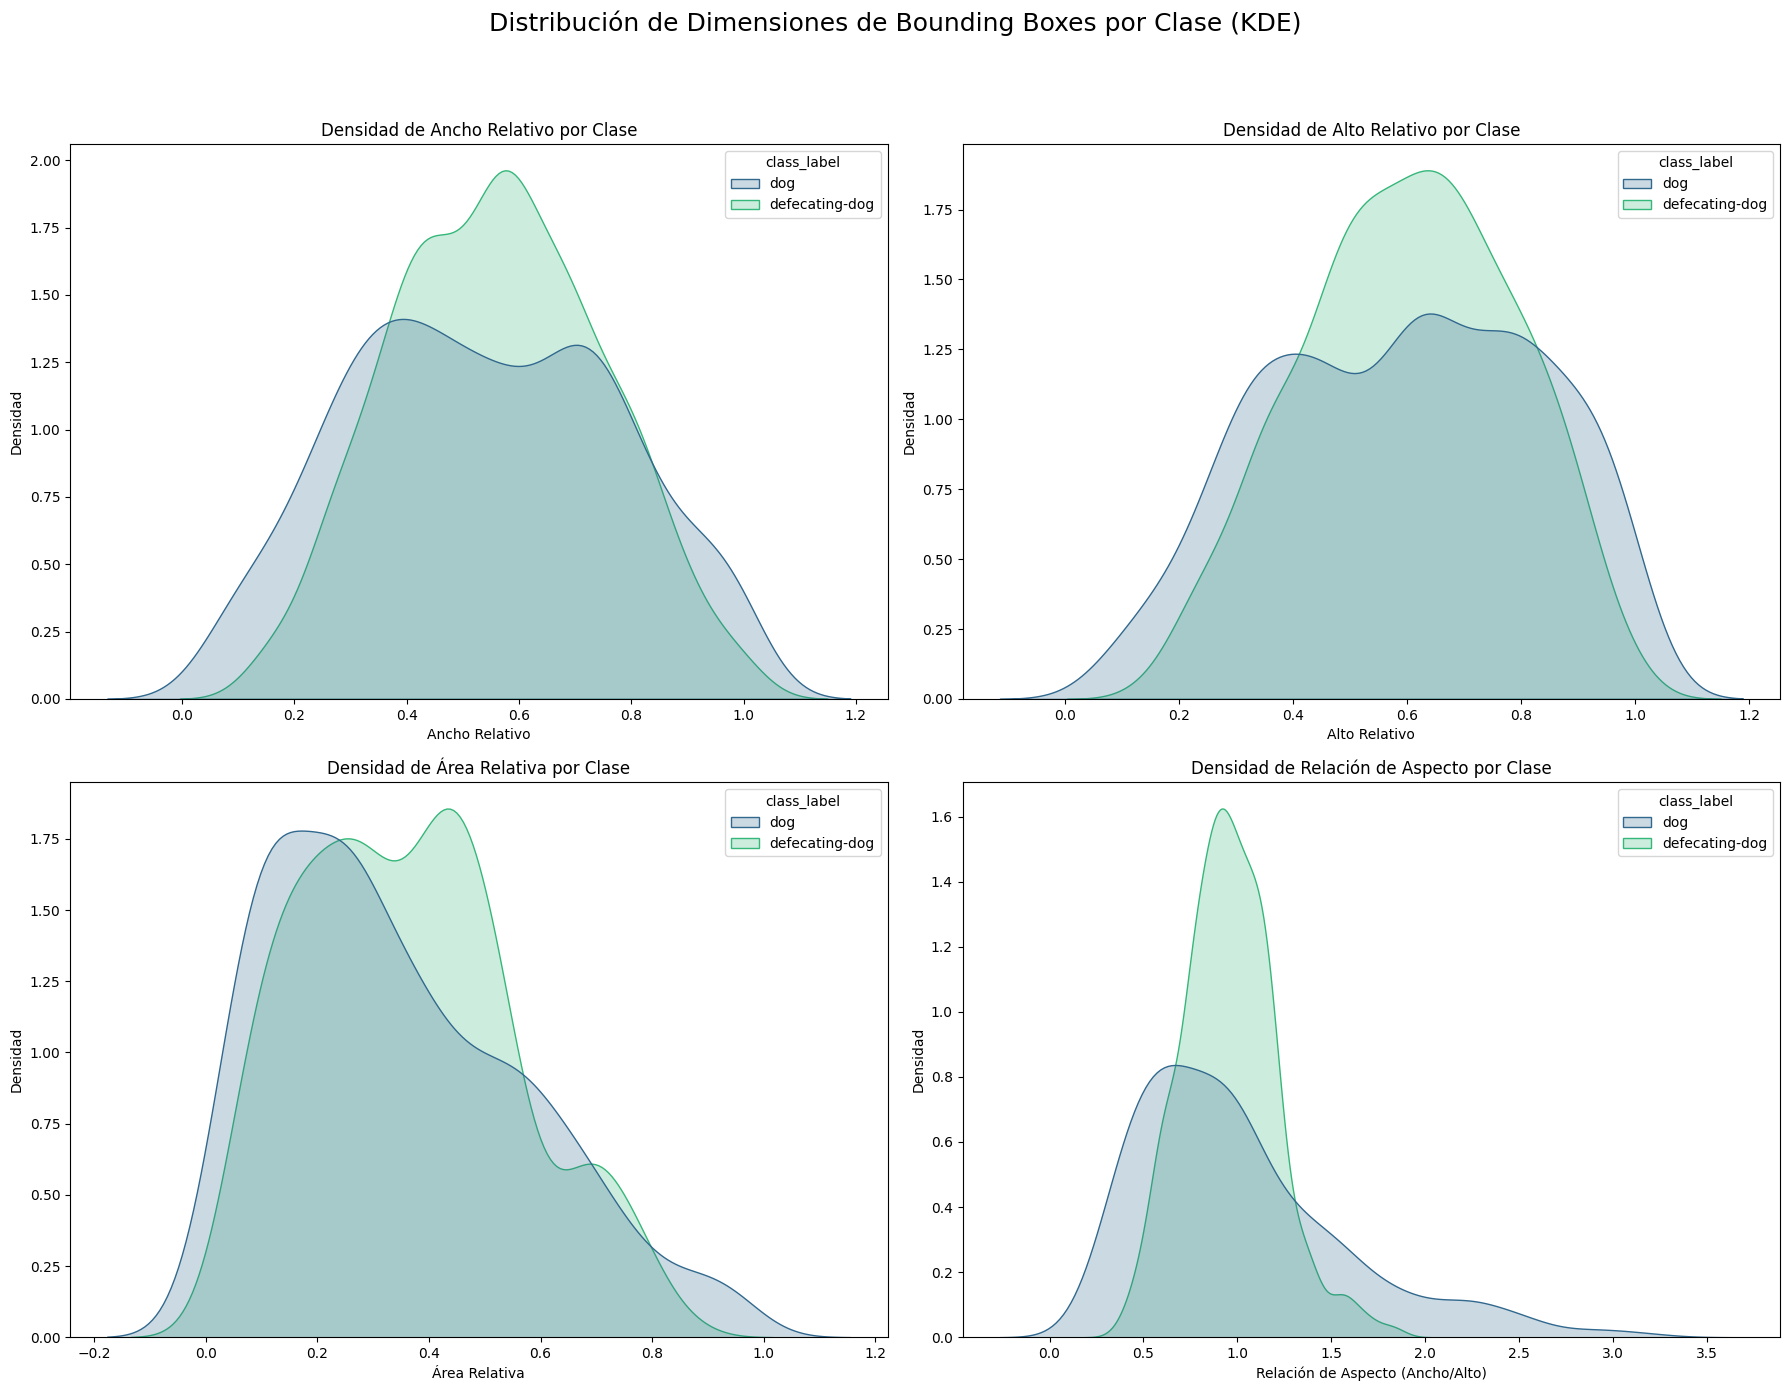


**Interpretación de los Gráficos de Densidad por Clase:**

Estos gráficos te permiten comparar las distribuciones de las dimensiones de las bounding boxes entre las diferentes clases. Busca:

- **Picos Desplazados:** Si los picos de las densidades para una clase están significativamente desplazados respecto a otra, sugiere que los objetos de esa clase son consistentemente más grandes/pequeños o tienen proporciones diferentes. Por ejemplo, una clase podría tener objetos con un 'width' promedio menor.

- **Diferencias en la Dispersión:** Una curva más ancha indica una mayor variabilidad en el tamaño o forma de los objetos dentro de esa clase. Una curva más estrecha sugiere objetos más uniformes.

- **Outliers Potenciales:** Aunque el KDE suaviza, las colas muy largas en una dirección para una clase específica podrían indicar la presencia de outliers o casos extremos que son más comunes en esa clase. Por ejemplo, una cola de 'aspect_ratio' muy extendida para una clase podría indicar que 

In [ ]:
if not df_annotations.empty:
    print("### Gráficos de Densidad (KDE) por Clase para Dimensiones de Bounding Boxes\n")

    # Asegurarse de que 'class_label' exista para usarlo como hue
    if 'class_label' not in df_annotations.columns:
        if 'class_names' in locals() and class_names:
            df_annotations['class_label'] = df_annotations['class_id'].apply(lambda x: class_names[x] if x < len(class_names) else f'Unknown {x}')
        else:
            df_annotations['class_label'] = df_annotations['class_id'].astype(str)

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('Distribución de Dimensiones de Bounding Boxes por Clase (KDE)', fontsize=18, y=1.02)

    # KDE para Ancho por Clase
    sns.kdeplot(data=df_annotations, x='width', hue='class_label', fill=True, ax=axes[0, 0], palette='viridis', common_norm=False)
    axes[0, 0].set_title('Densidad de Ancho Relativo por Clase')
    axes[0, 0].set_xlabel('Ancho Relativo')
    axes[0, 0].set_ylabel('Densidad')

    # KDE para Alto por Clase
    sns.kdeplot(data=df_annotations, x='height', hue='class_label', fill=True, ax=axes[0, 1], palette='viridis', common_norm=False)
    axes[0, 1].set_title('Densidad de Alto Relativo por Clase')
    axes[0, 1].set_xlabel('Alto Relativo')
    axes[0, 1].set_ylabel('Densidad')

    # KDE para Área por Clase
    sns.kdeplot(data=df_annotations, x='area', hue='class_label', fill=True, ax=axes[1, 0], palette='viridis', common_norm=False)
    axes[1, 0].set_title('Densidad de Área Relativa por Clase')
    axes[1, 0].set_xlabel('Área Relativa')
    axes[1, 0].set_ylabel('Densidad')

    # KDE para Relación de Aspecto por Clase
    # Asegurarse de dropear NaNs para KDE
    sns.kdeplot(data=df_annotations.dropna(subset=['aspect_ratio']), x='aspect_ratio', hue='class_label', fill=True, ax=axes[1, 1], palette='viridis', common_norm=False)
    axes[1, 1].set_title('Densidad de Relación de Aspecto por Clase')
    axes[1, 1].set_xlabel('Relación de Aspecto (Ancho/Alto)')
    axes[1, 1].set_ylabel('Densidad')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

    print("\n**Interpretación de los Gráficos de Densidad por Clase:**\n")
    print("Estos gráficos te permiten comparar las distribuciones de las dimensiones de las bounding boxes entre las diferentes clases. Busca:\n")
    print("- **Picos Desplazados:** Si los picos de las densidades para una clase están significativamente desplazados respecto a otra, sugiere que los objetos de esa clase son consistentemente más grandes/pequeños o tienen proporciones diferentes. Por ejemplo, una clase podría tener objetos con un 'width' promedio menor.\n")
    print("- **Diferencias en la Dispersión:** Una curva más ancha indica una mayor variabilidad en el tamaño o forma de los objetos dentro de esa clase. Una curva más estrecha sugiere objetos más uniformes.\n")
    print("- **Outliers Potenciales:** Aunque el KDE suaviza, las colas muy largas en una dirección para una clase específica podrían indicar la presencia de outliers o casos extremos que son más comunes en esa clase. Por ejemplo, una cola de 'aspect_ratio' muy extendida para una clase podría indicar que esa clase incluye objetos muy alargados o muy anchos.\n")
    print("Esta visualización es clave para entender si las características morfológicas (tamaño y forma de los objetos) varían significativamente entre tus clases, lo que puede tener implicaciones para el rendimiento del modelo en cada clase y para las estrategias de mejora de datos.")
else:
    print("No hay datos de anotaciones para generar los gráficos de densidad por clase.")

### 5. Identificación de valores atipicos: Verificación de Outliers

Aquí visualizaremos las distribuciones de `width`, `height`, `area` y `aspect_ratio` para identificar posibles outliers. Usaremos box plots e histogramas para identificarlos.

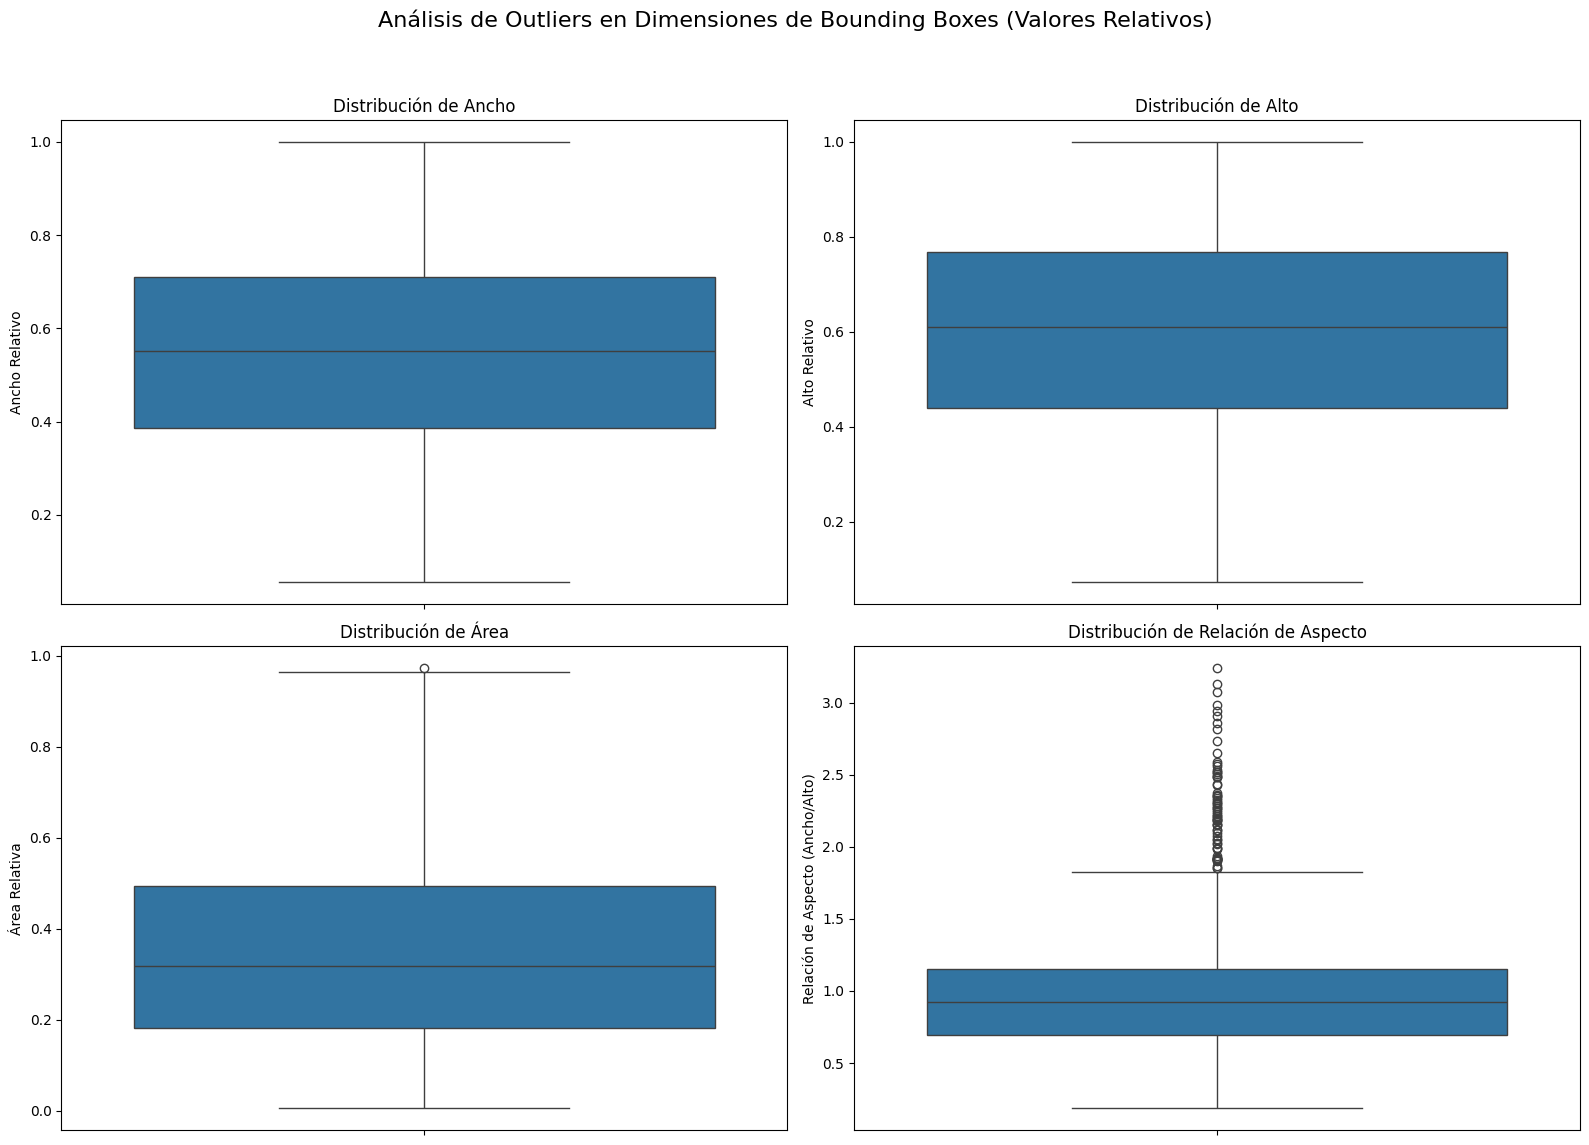


Histo_gramas para una visión más detallada de la distribución (filtrando valores extremos para mejor visualización):


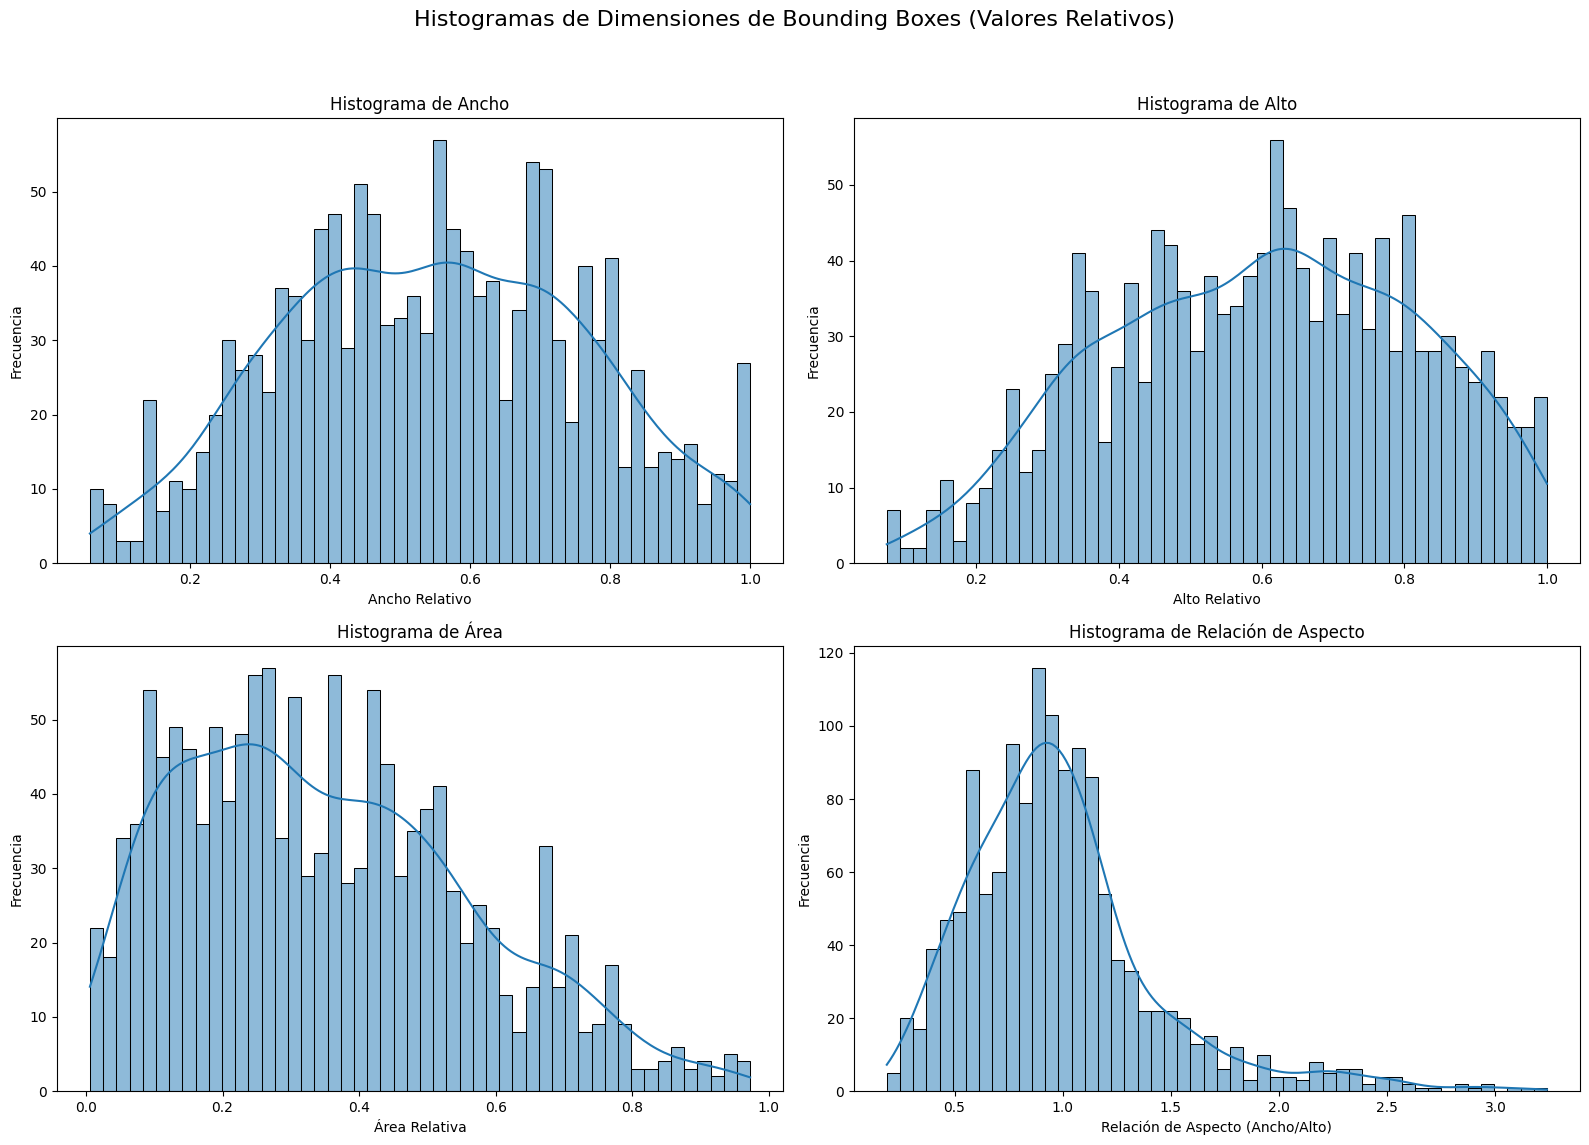


Posibles outliers (ej. cajas muy pequeñas/grandes, o con relaciones de aspecto extremas) pueden ser identificados visualmente en estos gráficos.
Puedes considerar filtros basados en percentiles o rangos intercuartílicos si necesitas una identificación numérica.


In [ ]:
if not df_annotations.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Análisis de Outliers en Dimensiones de Bounding Boxes (Valores Relativos)', fontsize=16)

    # Box Plot para Ancho
    sns.boxplot(y=df_annotations['width'], ax=axes[0, 0])
    axes[0, 0].set_title('Distribución de Ancho')
    axes[0, 0].set_ylabel('Ancho Relativo')

    # Box Plot para Alto
    sns.boxplot(y=df_annotations['height'], ax=axes[0, 1])
    axes[0, 1].set_title('Distribución de Alto')
    axes[0, 1].set_ylabel('Alto Relativo')

    # Box Plot para Área
    sns.boxplot(y=df_annotations['area'], ax=axes[1, 0])
    axes[1, 0].set_title('Distribución de Área')
    axes[1, 0].set_ylabel('Área Relativa')

    # Box Plot para Relación de Aspecto (filtrar NaN si hay)
    sns.boxplot(y=df_annotations['aspect_ratio'].dropna(), ax=axes[1, 1])
    axes[1, 1].set_title('Distribución de Relación de Aspecto')
    axes[1, 1].set_ylabel('Relación de Aspecto (Ancho/Alto)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\nHisto_gramas para una visión más detallada de la distribución (filtrando valores extremos para mejor visualización):")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Histogramas de Dimensiones de Bounding Boxes (Valores Relativos)', fontsize=16)

    # Histograma para Ancho
    sns.histplot(df_annotations['width'], bins=50, kde=True, ax=axes[0, 0])
    axes[0, 0].set_title('Histograma de Ancho')
    axes[0, 0].set_xlabel('Ancho Relativo')
    axes[0, 0].set_ylabel('Frecuencia')

    # Histograma para Alto
    sns.histplot(df_annotations['height'], bins=50, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('Histograma de Alto')
    axes[0, 1].set_xlabel('Alto Relativo')
    axes[0, 1].set_ylabel('Frecuencia')

    # Histograma para Área (filtrar outliers extremos para mejor visualización si es necesario)
    sns.histplot(df_annotations['area'], bins=50, kde=True, ax=axes[1, 0])
    axes[1, 0].set_title('Histograma de Área')
    axes[1, 0].set_xlabel('Área Relativa')
    axes[1, 0].set_ylabel('Frecuencia')

    # Histograma para Relación de Aspecto (filtrar NaN y valores extremos)
    sns.histplot(df_annotations['aspect_ratio'].dropna(), bins=50, kde=True, ax=axes[1, 1])
    axes[1, 1].set_title('Histograma de Relación de Aspecto')
    axes[1, 1].set_xlabel('Relación de Aspecto (Ancho/Alto)')
    axes[1, 1].set_ylabel('Frecuencia')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\nPosibles outliers (ej. cajas muy pequeñas/grandes, o con relaciones de aspecto extremas) pueden ser identificados visualmente en estos gráficos.")
    print("Puedes considerar filtros basados en percentiles o rangos intercuartílicos si necesitas una identificación numérica.")

else:
    print("No hay datos de anotaciones para la verificación de outliers.")

**Gráficos para la Identificación Visual de Outliers:**



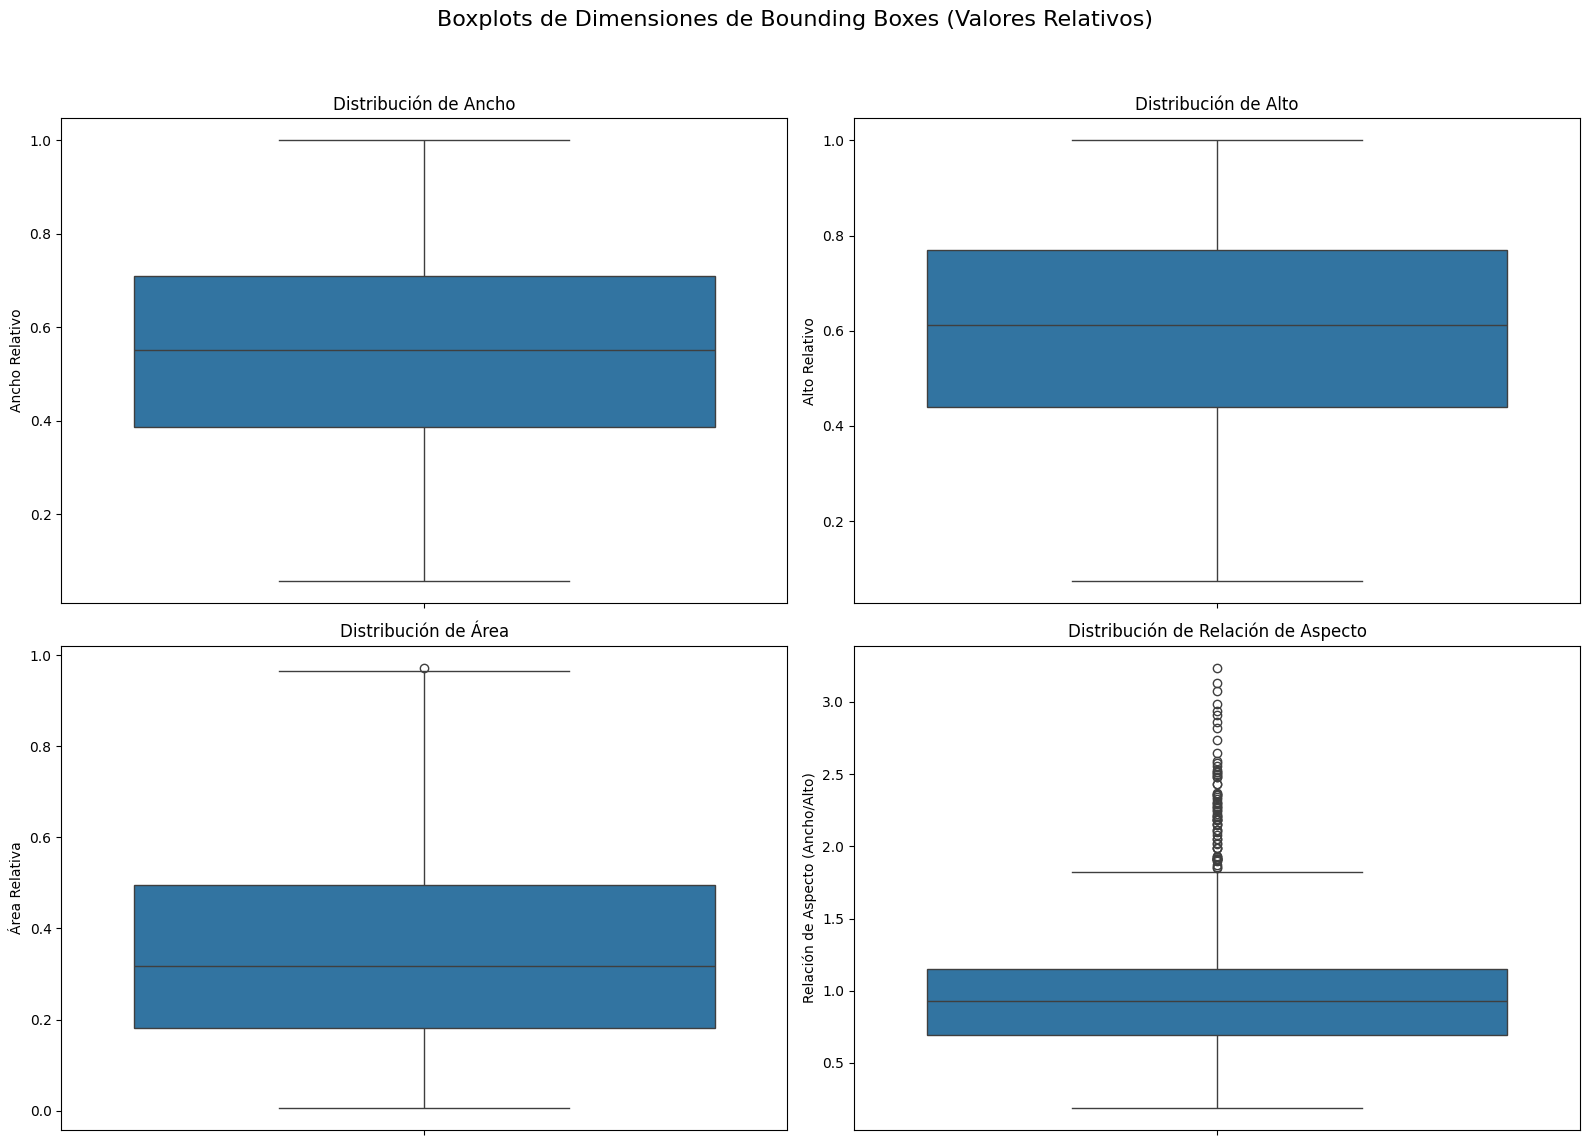


*Interpretación de Boxplots: Los puntos individuales fuera de los 'bigotes' de los boxplots son los outliers. Indican valores significativamente más grandes o más pequeños que la mayoría de los datos. En nuestro caso, observamos outliers en 'area' y 'aspect_ratio'.*



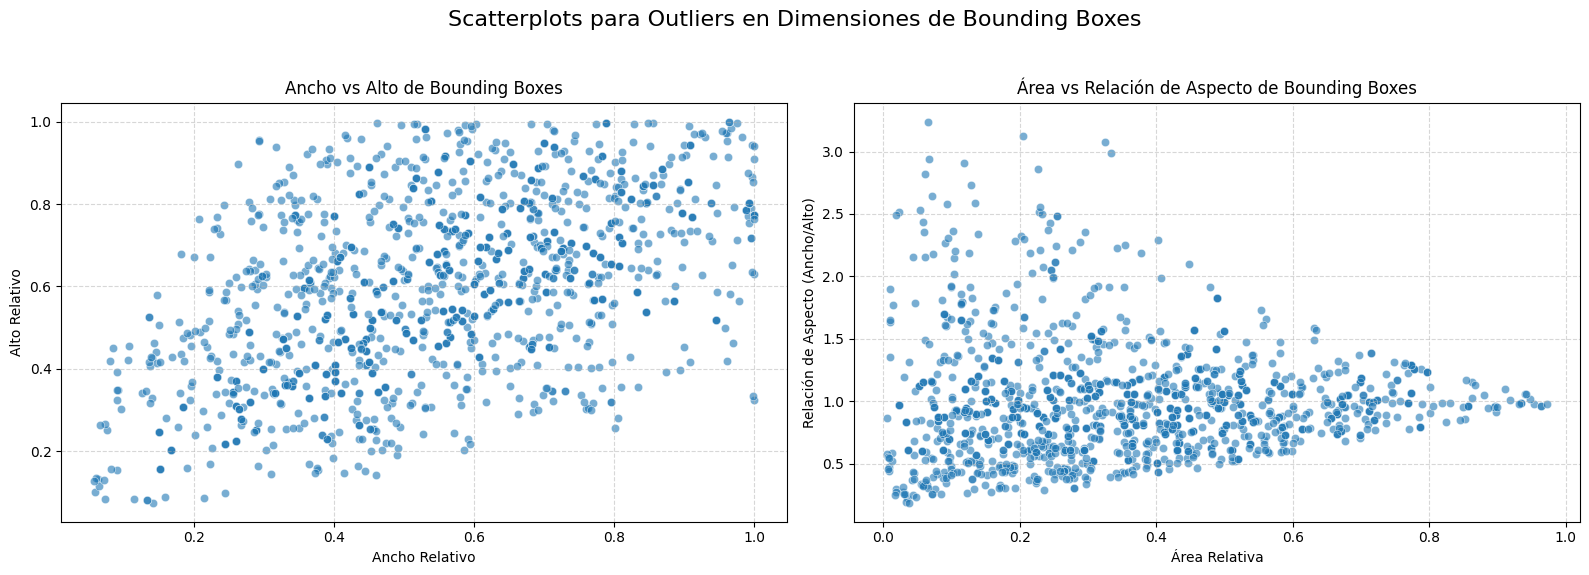


*Interpretación de Scatterplots: Los scatterplots nos permiten ver combinaciones inusuales de dos variables. Por ejemplo, puntos muy alejados del clúster principal en el gráfico de 'Ancho vs Alto' podrían ser cajas muy estrechas y altas o muy anchas y bajas. En el gráfico de 'Área vs Relación de Aspecto', podemos identificar objetos con un área muy grande pero una relación de aspecto extrema, o viceversa.*

**Análisis y Posible Tratamiento de Outliers:**

Una vez identificados los outliers, el siguiente paso es analizarlos contextualmente:
- **¿Son Errores de Anotación?** A veces, un outlier es simplemente un error humano durante el etiquetado (ej. caja mal dibujada, clase errónea). Si se confirma un error, la anotación debe corregirse en el dataset original. Para ello, puedes usar el `image_filename` para localizar la imagen y su anotación.
- **¿Son Casos Reales (pero inusuales)?** En otros casos, un outlier representa un objeto real pero poco común (ej. un perro muy pequeño a gran d

In [ ]:
if not df_annotations.empty:
    print("**Gráficos para la Identificación Visual de Outliers:**\n")

    # 1. Boxplots (re-presentando para completitud de la sección)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Boxplots de Dimensiones de Bounding Boxes (Valores Relativos)', fontsize=16)

    sns.boxplot(y=df_annotations['width'], ax=axes[0, 0])
    axes[0, 0].set_title('Distribución de Ancho')
    axes[0, 0].set_ylabel('Ancho Relativo')

    sns.boxplot(y=df_annotations['height'], ax=axes[0, 1])
    axes[0, 1].set_title('Distribución de Alto')
    axes[0, 1].set_ylabel('Alto Relativo')

    sns.boxplot(y=df_annotations['area'], ax=axes[1, 0])
    axes[1, 0].set_title('Distribución de Área')
    axes[1, 0].set_ylabel('Área Relativa')

    sns.boxplot(y=df_annotations['aspect_ratio'].dropna(), ax=axes[1, 1])
    axes[1, 1].set_title('Distribución de Relación de Aspecto')
    axes[1, 1].set_ylabel('Relación de Aspecto (Ancho/Alto)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n*Interpretación de Boxplots: Los puntos individuales fuera de los 'bigotes' de los boxplots son los outliers. Indican valores significativamente más grandes o más pequeños que la mayoría de los datos. En nuestro caso, observamos outliers en 'area' y 'aspect_ratio'.*\n")

    # 2. Scatterplots para identificar outliers bivariados o patrones inusuales
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Scatterplots para Outliers en Dimensiones de Bounding Boxes', fontsize=16)

    sns.scatterplot(x=df_annotations['width'], y=df_annotations['height'], ax=axes[0], alpha=0.6)
    axes[0].set_title('Ancho vs Alto de Bounding Boxes')
    axes[0].set_xlabel('Ancho Relativo')
    axes[0].set_ylabel('Alto Relativo')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    sns.scatterplot(x=df_annotations['area'], y=df_annotations['aspect_ratio'], ax=axes[1], alpha=0.6)
    axes[1].set_title('Área vs Relación de Aspecto de Bounding Boxes')
    axes[1].set_xlabel('Área Relativa')
    axes[1].set_ylabel('Relación de Aspecto (Ancho/Alto)')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n*Interpretación de Scatterplots: Los scatterplots nos permiten ver combinaciones inusuales de dos variables. Por ejemplo, puntos muy alejados del clúster principal en el gráfico de 'Ancho vs Alto' podrían ser cajas muy estrechas y altas o muy anchas y bajas. En el gráfico de 'Área vs Relación de Aspecto', podemos identificar objetos con un área muy grande pero una relación de aspecto extrema, o viceversa.*\n")

    print("**Análisis y Posible Tratamiento de Outliers:**\n")
    print("Una vez identificados los outliers, el siguiente paso es analizarlos contextualmente:")
    print("- **¿Son Errores de Anotación?** A veces, un outlier es simplemente un error humano durante el etiquetado (ej. caja mal dibujada, clase errónea). Si se confirma un error, la anotación debe corregirse en el dataset original. Para ello, puedes usar el `image_filename` para localizar la imagen y su anotación.")
    print("- **¿Son Casos Reales (pero inusuales)?** En otros casos, un outlier representa un objeto real pero poco común (ej. un perro muy pequeño a gran distancia, un objeto muy alargado debido a la perspectiva). Ignorar estos casos puede llevar a que el modelo no los detecte correctamente en escenarios reales. Considera:")
    print("  - **Impacto en el Modelo:** Unos pocos outliers pueden no ser problemáticos, pero un gran número podría sesgar el entrenamiento, especialmente si se utilizan métricas sensibles a los extremos. Los modelos de detección de objetos, como YOLOv8, son relativamente robustos a cierta variabilidad, pero los valores extremos consistentemente pueden dificultar el aprendizaje.")
    print("  - **Aumentar Datos Similares:** Si son casos reales importantes, podrías buscar más imágenes que contengan estos tipos de outliers para que el modelo aprenda a manejarlos. Técnicas de aumento de datos (data augmentation) también pueden ayudar a introducir más variabilidad.")
    print("- **Estrategias de Manejo:**")
    print("  - **No hacer nada:** Si son pocos y no afectan el rendimiento, a veces es la mejor opción.")
    print("  - **Transformación de datos:** En algunos análisis (no tanto en la detección de objetos directa), las transformaciones logarítmicas o de potencia pueden reducir el impacto de los outliers.")
    print("  - **Modelos robustos:** Elegir algoritmos que sean inherentemente más robustos a los outliers.")
    print("  - **Eliminación (con precaución):** Solo si se confirman errores y/o si el outlier es extremadamente perjudicial y no representa ningún caso de interés. **Esta opción debe ser el último recurso y muy bien justificada**, ya que eliminar datos reales reduce la información para el modelo.")
else:
    print("No hay datos de anotaciones para realizar la identificación de outliers.")

### 11. Visualización y Listado de Outliers para la Clase 'dog' (Aspect Ratio)

Se encontraron 27 outliers en 'aspect_ratio' para la clase 'dog'.

**Rutas y miniaturas de las primeras imágenes outlier (Clase 'dog', Aspect Ratio):**

  - /content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8/train/images/-_png_jpg.rf.64d2af4e37032ae47a545646cae9186b.jpg


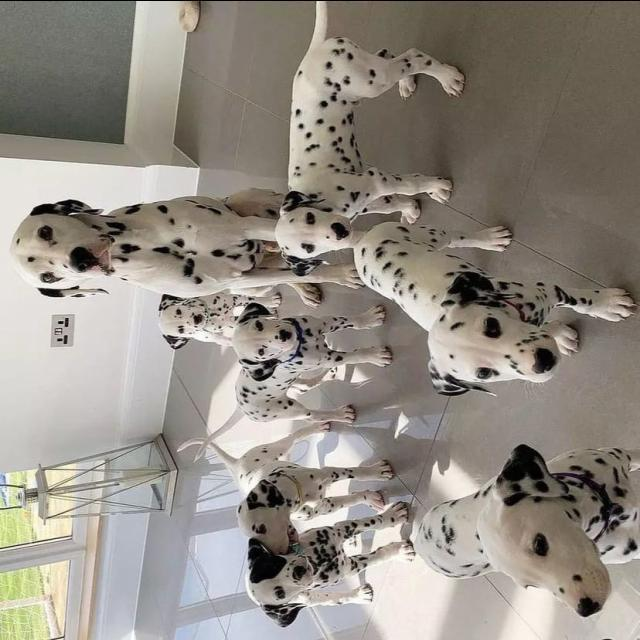

  - /content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8/train/images/-22-_jpg.rf.27478afed07b0a2995d0688e88232e2c.jpg


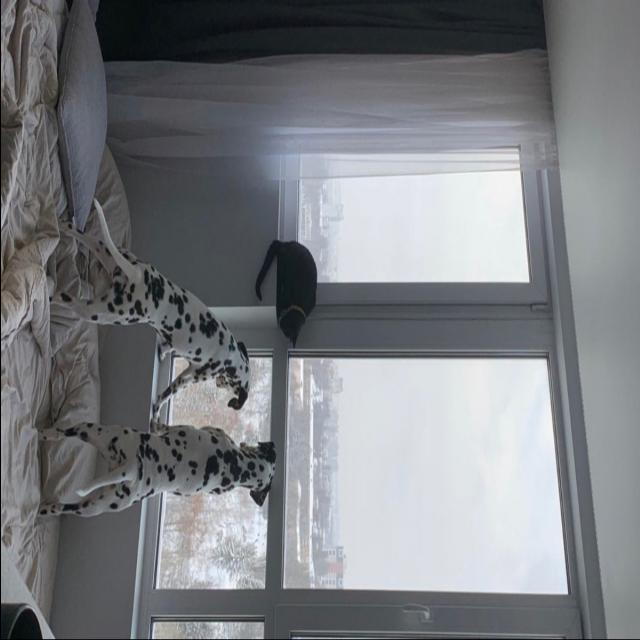

  - /content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8/train/images/youtube-95_jpg.rf.eaf700c6e78f582413e02ab85e5a02b8.jpg


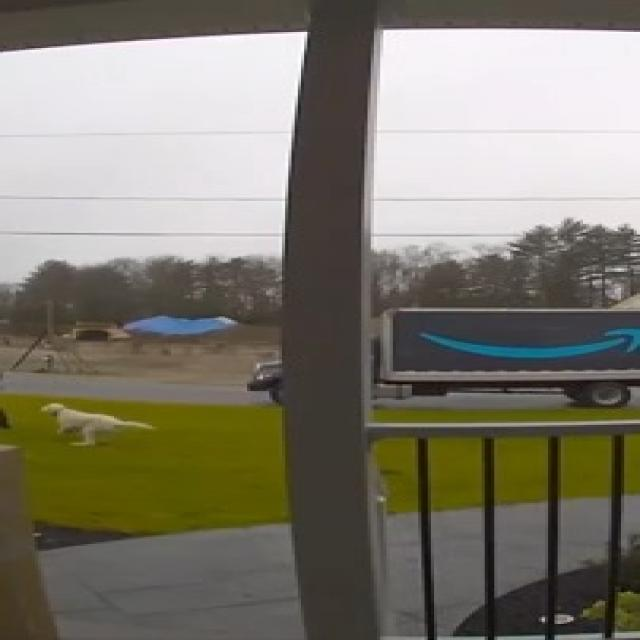

  - /content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8/train/images/-_-_jpg.rf.8d2970b66b0de4d4a6211d70d73f9a8d.jpg


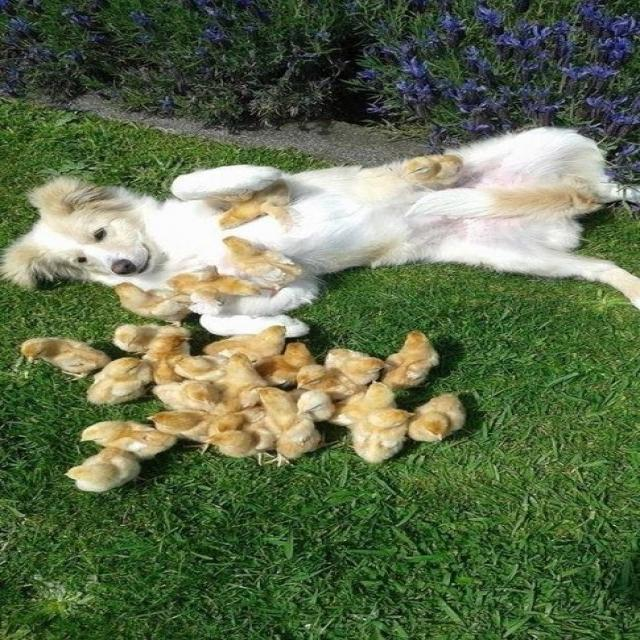

  - /content/drive/MyDrive/Proyecto Integrador MIA/DataSet/Dataset Dog and DogDef Balanced 03abril2026/DOG.v3i.yolov8/train/images/19_jpg.rf.43897cd0f7d0ea9bafb45acf414f0768.jpg


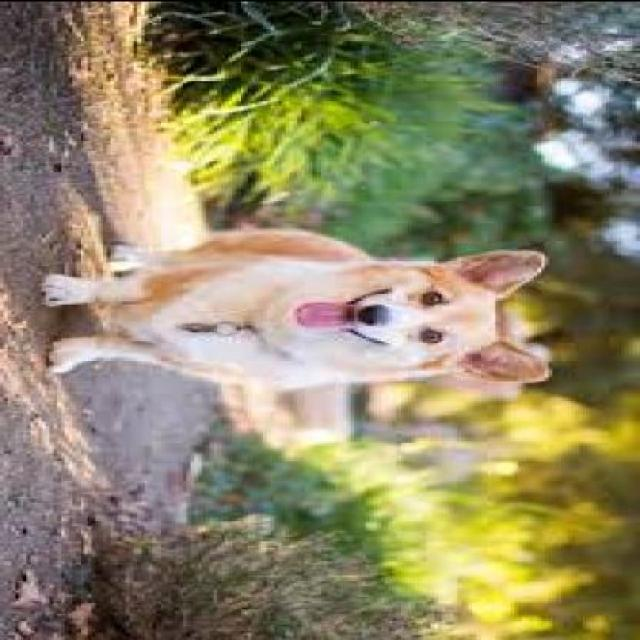

(Mostrando las primeras 5 de 24 imágenes de outliers. Puedes inspeccionar las rutas para las demás.)


**Listado Completo de Anotaciones Outlier (Clase 'dog', Aspect Ratio):**


,image_filename,class_id,width,height,area,aspect_ratio
207,-_png_jpg.rf.64d2af4e37032ae47a545646cae9186b,1,0.243750,0.096875,0.023613,2.516129
209,-_png_jpg.rf.64d2af4e37032ae47a545646cae9186b,1,0.585938,0.201563,0.118103,2.906977
250,-22-_jpg.rf.27478afed07b0a2995d0688e88232e2c,1,0.376563,0.154688,0.058250,2.434343
262,youtube-95_jpg.rf.eaf700c6e78f582413e02ab85e5a...,1,0.214062,0.085938,0.018396,2.490909
292,-_-_jpg.rf.8d2970b66b0de4d4a6211d70d73f9a8d,1,1.000000,0.325000,0.325000,3.076923
350,19_jpg.rf.43897cd0f7d0ea9bafb45acf414f0768,1,0.801562,0.256250,0.205400,3.128049
431,youtube-17_jpg.rf.5ee95b4983e963e27f81fd0daeff...,1,0.794703,0.320167,0.254437,2.482154
520,youtube-17_jpg.rf.f2acc8fc6b139c7bf81e5d8e0c61...,1,0.795312,0.320312,0.254749,2.482927
585,-22-_jpg.rf.54e9d52edf961875640bcb2c9f03e2be,1,0.375000,0.159375,0.059766,2.352941
604,-15-_jpg.rf.0ef7db0015f3a92b48805aad6a7e893c,1,0.434375,0.164062,0.071265,2.647619



**Posibles Acciones a Realizar con estos Outliers:**

1.  **Revisión Manual de Anotaciones:** Es el paso más crítico. Utiliza el `image_filename` para localizar las imágenes originales y sus archivos de anotación. Revisa visualmente si la bounding box está dibujada correctamente, si la clase es la adecuada y si la forma del objeto es tan extrema como lo indica el 'aspect_ratio'.
    -   **Errores:** Si encuentras errores (ej. la caja incluye parte del fondo, está mal alineada, o el objeto es realmente de otra clase), corrige la anotación en tu dataset original.
    -   **Casos Genuinos pero Extremos:** Si la anotación es correcta y el 'dog' realmente tiene una relación de aspecto tan inusual (ej. un perro muy delgado y alto, o muy bajo y ancho debido a la perspectiva o raza), esto indica que tu modelo necesitará aprender a detectar tales variaciones. Considera añadir más ejemplos de este tipo (si es posible) o aplicar técnicas de data augmentation que generen estas variaciones.
2.  **

In [ ]:
from IPython.display import Image, display as idisplay
import os

if not df_annotations.empty:
    print("### 11. Visualización y Listado de Outliers para la Clase 'dog' (Aspect Ratio)\n")

    # Asegurarse de que class_names esté disponible
    if 'class_names' not in locals() or class_names is None:
        unique_class_ids = df_annotations['class_id'].unique()
        class_names_map = {cid: f'Class {cid}' for cid in unique_class_ids}
    else:
        class_names_map = {i: name for i, name in enumerate(class_names)}

    dog_class_id = None
    for cid, name in class_names_map.items():
        if name == 'dog':
            dog_class_id = cid
            break

    if dog_class_id is None:
        print("Advertencia: La clase 'dog' no fue encontrada en los nombres de clase. No se pueden listar sus outliers.")
    else:
        df_dog_class = df_annotations[df_annotations['class_id'] == dog_class_id].copy()

        if not df_dog_class.empty:
            col = 'aspect_ratio'

            # Calcular IQR para la clase 'dog' y la columna 'aspect_ratio'
            Q1 = df_dog_class[col].quantile(0.25)
            Q3 = df_dog_class[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Identificar los outliers
            outliers_dog_aspect_ratio = df_dog_class[(df_dog_class[col] < lower_bound) | (df_dog_class[col] > upper_bound)]

            print(f"Se encontraron {len(outliers_dog_aspect_ratio)} outliers en 'aspect_ratio' para la clase 'dog'.\n")

            if not outliers_dog_aspect_ratio.empty:
                print("**Rutas y miniaturas de las primeras imágenes outlier (Clase 'dog', Aspect Ratio):**\n")

                # Helper function to find image path (assuming image_files from a previous cell is available)
                def find_image_path(image_base_name, image_files_set, dataset_root_path):
                    # Iterate through potential image directories
                    subdirs = ['train', 'valid', 'test']
                    for subdir in subdirs:
                        image_dir = os.path.join(dataset_root_path, subdir, 'images')
                        if os.path.exists(image_dir):
                            potential_path_jpg = os.path.join(image_dir, f'{image_base_name}.jpg')
                            if os.path.exists(potential_path_jpg):
                                return potential_path_jpg
                            potential_path_png = os.path.join(image_dir, f'{image_base_name}.png')
                            if os.path.exists(potential_path_png):
                                return potential_path_png
                    return None

                outlier_image_paths = []
                for filename_base in outliers_dog_aspect_ratio['image_filename'].unique():
                    full_path = find_image_path(filename_base, image_files, dataset_path)
                    if full_path:
                        outlier_image_paths.append(full_path)

                if outlier_image_paths:
                    for i, img_path in enumerate(outlier_image_paths[:5]): # Display up to 5 images
                        print(f"  - {img_path}")
                        idisplay(Image(filename=img_path, width=200)) # Display small images
                    if len(outlier_image_paths) > 5:
                        print(f"(Mostrando las primeras 5 de {len(outlier_image_paths)} imágenes de outliers. Puedes inspeccionar las rutas para las demás.)\n")
                else:
                    print("No se encontraron rutas de imagen para los outliers detectados.")

                print("\n**Listado Completo de Anotaciones Outlier (Clase 'dog', Aspect Ratio):**")
                display(outliers_dog_aspect_ratio[['image_filename', 'class_id', 'width', 'height', 'area', 'aspect_ratio']]) # Display all outliers

                print("\n**Posibles Acciones a Realizar con estos Outliers:**\n")
                print("1.  **Revisión Manual de Anotaciones:** Es el paso más crítico. Utiliza el `image_filename` para localizar las imágenes originales y sus archivos de anotación. Revisa visualmente si la bounding box está dibujada correctamente, si la clase es la adecuada y si la forma del objeto es tan extrema como lo indica el 'aspect_ratio'.")
                print("    -   **Errores:** Si encuentras errores (ej. la caja incluye parte del fondo, está mal alineada, o el objeto es realmente de otra clase), corrige la anotación en tu dataset original.")
                print("    -   **Casos Genuinos pero Extremos:** Si la anotación es correcta y el 'dog' realmente tiene una relación de aspecto tan inusual (ej. un perro muy delgado y alto, o muy bajo y ancho debido a la perspectiva o raza), esto indica que tu modelo necesitará aprender a detectar tales variaciones. Considera añadir más ejemplos de este tipo (si es posible) o aplicar técnicas de data augmentation que generen estas variaciones.")
                print("2.  **Impacto en el Modelo:** Los modelos de detección de objetos como YOLOv8 utilizan 'anchors' (cajas de anclaje) con relaciones de aspecto predefinidas. Si hay muchos objetos con relaciones de aspecto muy diferentes a tus anchors, el modelo podría tener dificultades. Identificar estos outliers te ayuda a decidir si necesitas ajustar los anchors o si el modelo puede aprender a generalizar.")
                print("3.  **Filtrado (con precaución):** Si se determina que son errores de anotación y no puedes corregirlos, o si son casos genuinos pero tan raros que preferirías que el modelo no se 'confunda' con ellos, podrías considerar eliminarlos del conjunto de entrenamiento. Sin embargo, esto debe hacerse con extrema cautela y solo si estás seguro de que no estás eliminando información valiosa.")
            else:
                print("No se encontraron outliers de 'aspect_ratio' para la clase 'dog' con los criterios IQR.")
        else:
            print("No hay anotaciones para la clase 'dog' en el DataFrame.")
else:
    print("No hay datos de anotaciones para realizar este análisis.")

### 6. Análisis de Correlaciones

Los valores atípicos, o outliers, son observaciones que se desvían significativamente de otras observaciones. Su identificación es crucial porque pueden ser el resultado de errores en la recolección de datos o pueden indicar variaciones genuinas e importantes en el dataset que necesitan atención especial. Una vez identificados, es fundamental analizar si estos valores representan un error que debe corregirse o si son un caso real que el modelo debe aprender, y cuál podría ser su impacto en el rendimiento del modelo.

Ya hemos visto boxplots en la sección de Verificación de Outliers, pero los incluimos nuevamente aquí para una referencia completa de esta sección dedicada. Complementaremos esto con scatterplots para observar relaciones bivariadas.

### 6. Análisis de Correlaciones entre Dimensiones de Bounding Boxes

**Matriz de Correlación:**



,width,height,area,aspect_ratio
width,1.000000,0.507466,0.866373,0.434581
height,0.507466,1.000000,0.825224,-0.456151
area,0.866373,0.825224,1.000000,-0.006242
aspect_ratio,0.434581,-0.456151,-0.006242,1.000000



**Mapa de Calor de Correlación:**



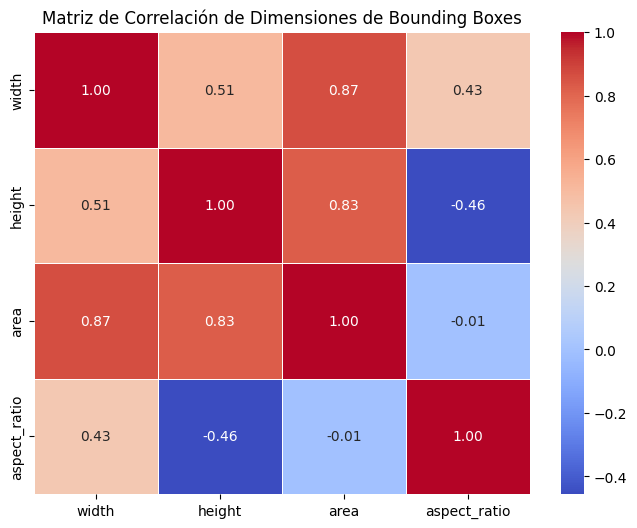


**Interpretación del Análisis de Correlaciones:**

La matriz de correlación y el mapa de calor nos muestran la fuerza y dirección de la relación lineal entre cada par de variables. Los valores varían de -1 a 1:
-   **1 (o cercano a 1):** Correlación positiva fuerte. A medida que una variable aumenta, la otra tiende a aumentar (ej. 'width' y 'area').
-   **-1 (o cercano a -1):** Correlación negativa fuerte. A medida que una variable aumenta, la otra tiende a disminuir (ej. no es común en este tipo de datos).
-   **0 (o cercano a 0):** No hay una relación lineal fuerte. Los cambios en una variable no están asociados con un patrón consistente en la otra.

**Observaciones Clave:**
-   **Ancho (width) y Alto (height):** A menudo, el ancho y el alto de las bounding boxes estarán positivamente correlacionados, ya que objetos más grandes en una dimensión suelen ser más grandes en la otra. Una correlación fuerte aquí indicaría que los objetos tienden a escalar de manera uniforme.
-   **Área (a

In [ ]:
if not df_annotations.empty:
    print("### 6. Análisis de Correlaciones entre Dimensiones de Bounding Boxes\n")
    print("**Matriz de Correlación:**\n")

    # Seleccionar las columnas numéricas de interés
    numerical_cols = ['width', 'height', 'area', 'aspect_ratio']
    correlation_matrix = df_annotations[numerical_cols].corr()

    display(correlation_matrix)

    print("\n**Mapa de Calor de Correlación:**\n")

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Matriz de Correlación de Dimensiones de Bounding Boxes')
    plt.show()

    print("\n**Interpretación del Análisis de Correlaciones:**\n")
    print("La matriz de correlación y el mapa de calor nos muestran la fuerza y dirección de la relación lineal entre cada par de variables. Los valores varían de -1 a 1:")
    print("-   **1 (o cercano a 1):** Correlación positiva fuerte. A medida que una variable aumenta, la otra tiende a aumentar (ej. 'width' y 'area').")
    print("-   **-1 (o cercano a -1):** Correlación negativa fuerte. A medida que una variable aumenta, la otra tiende a disminuir (ej. no es común en este tipo de datos).")
    print("-   **0 (o cercano a 0):** No hay una relación lineal fuerte. Los cambios en una variable no están asociados con un patrón consistente en la otra.")

    print("\n**Observaciones Clave:**")
    print("-   **Ancho (width) y Alto (height):** A menudo, el ancho y el alto de las bounding boxes estarán positivamente correlacionados, ya que objetos más grandes en una dimensión suelen ser más grandes en la otra. Una correlación fuerte aquí indicaría que los objetos tienden a escalar de manera uniforme.")
    print("-   **Área (area):** Se espera una correlación positiva fuerte con el ancho y el alto, ya que el área es el producto de estas dos dimensiones. Esto es una verificación de la consistencia de los datos.")
    print("-   **Relación de Aspecto (aspect_ratio):** Su correlación con el ancho y el alto puede variar. Una correlación positiva con 'width' y negativa con 'height' sería esperada, ya que una relación de aspecto alta implica un objeto más ancho que alto, y viceversa. Su relación con el 'area' podría ser más compleja.")

    print("\n**¿Qué buscar en los resultados?**")
    print("-   **Correlaciones Fuertes (positivas o negativas):** Indican variables que se mueven juntas. Por ejemplo, si 'width' y 'height' tienen una correlación muy alta, significa que la mayoría de los objetos son proporcionalmente similares. Redundancias podrían existir si dos variables miden casi lo mismo.")
    print("-   **Variables Independientes:** Valores cercanos a cero sugieren que no hay una relación lineal directa entre esas variables. Esto puede ser útil para seleccionar características si se busca ortogonalidad.")
    print("-   **Influencia en la 'Variable Objetivo' (implícita):** Aunque no tenemos una 'variable objetivo' directa aquí como el rendimiento del modelo, entender las correlaciones entre las dimensiones nos ayuda a comprender mejor la morfología de los objetos que el modelo debe detectar. Por ejemplo, si hay objetos con baja área pero alta relación de aspecto, indica la necesidad de que el modelo maneje objetos muy delgados/alargados.")
else:
    print("No hay datos de anotaciones para realizar el análisis de correlaciones.")

### 7. Distribución de Clases

Visualizaremos la frecuencia de cada clase en el dataset.

/tmp/ipykernel_53184/3126921207.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_labels, y=class_counts.values, palette='viridis')


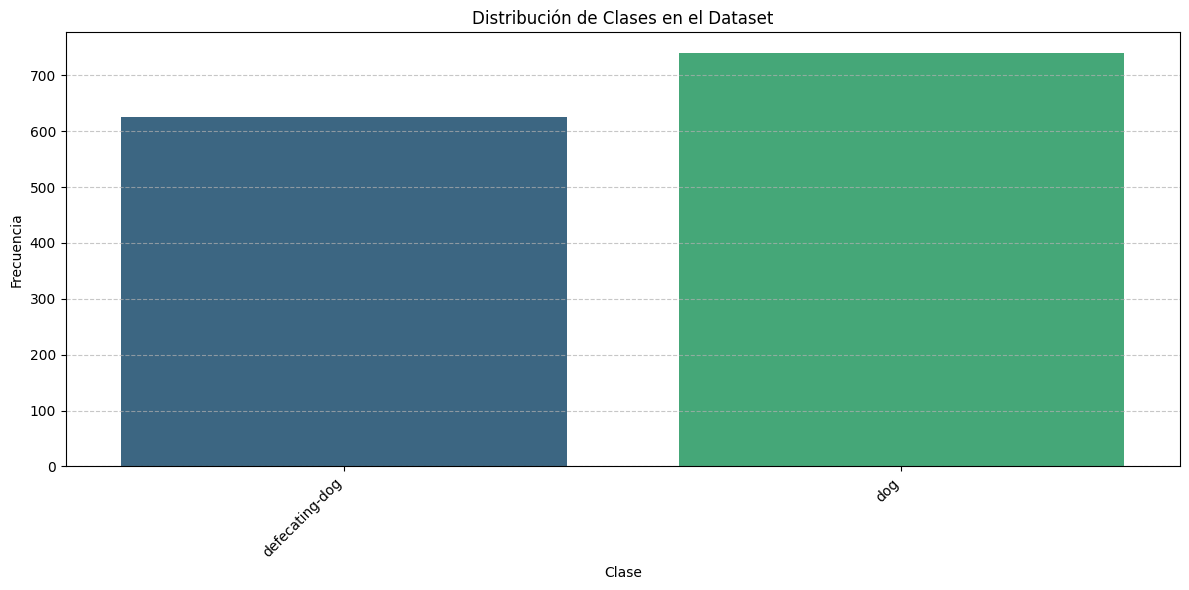

Conteo de instancias por clase:


,Class ID,Count,Class Name
0,0,626,defecating-dog
1,1,740,dog


In [ ]:
if not df_annotations.empty and 'class_id' in df_annotations.columns:
    class_counts = df_annotations['class_id'].value_counts().sort_index()

    if class_names:
        class_labels = [class_names[int(c_id)] if int(c_id) < len(class_names) else f'Unknown Class {c_id}' for c_id in class_counts.index]
    else:
        class_labels = [f'Class {int(c_id)}' for c_id in class_counts.index]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=class_labels, y=class_counts.values, palette='viridis')
    plt.title('Distribución de Clases en el Dataset')
    plt.xlabel('Clase')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("Conteo de instancias por clase:")
    class_counts_df = pd.DataFrame({'Class ID': class_counts.index, 'Count': class_counts.values})
    if class_names:
        class_counts_df['Class Name'] = class_counts_df['Class ID'].apply(lambda x: class_names[x] if x < len(class_names) else f'Unknown Class {x}')
    display(class_counts_df)
else:
    print("No hay datos de anotaciones o IDs de clase para mostrar la distribución de clases.")

### 7. Análisis de Variables Categóricas (Distribución de Clases)

**Tabla de Frecuencias de Clases:**


,Class ID,Count,Class Name
0,0,626,defecating-dog
1,1,740,dog


/tmp/ipykernel_53184/2107059636.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_labels, y=class_counts.values, palette='viridis')


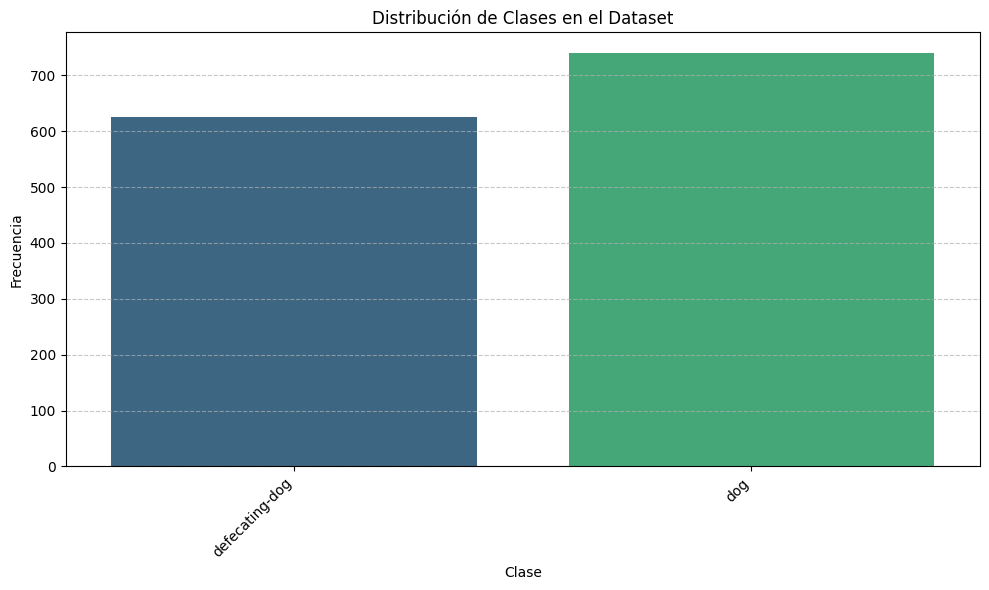


**Interpretación del Balance o Desbalance de Clases:**

El dataset contiene un total de 1366 anotaciones distribuidas en 2 clases.

- La clase 'defecating-dog' (ID: 0) tiene 626 instancias, lo que representa el 45.83% del total.
- La clase 'dog' (ID: 1) tiene 740 instancias, lo que representa el 54.17% del total.

**Análisis de Balance:**
Las clases parecen estar relativamente bien balanceadas, con una distribución equitativa de instancias entre ellas. Esto es ideal para el entrenamiento de modelos de clasificación/detección.


In [ ]:
print("### 7. Análisis de Variables Categóricas (Distribución de Clases)\n")

if not df_annotations.empty and 'class_id' in df_annotations.columns:
    class_counts = df_annotations['class_id'].value_counts().sort_index()

    if class_names:
        class_labels = [class_names[int(c_id)] if int(c_id) < len(class_names) else f'Unknown Class {c_id}' for c_id in class_counts.index]
    else:
        class_labels = [f'Class {int(c_id)}' for c_id in class_counts.index]

    print("**Tabla de Frecuencias de Clases:**")
    class_counts_df = pd.DataFrame({'Class ID': class_counts.index, 'Count': class_counts.values})
    if class_names:
        class_counts_df['Class Name'] = class_counts_df['Class ID'].apply(lambda x: class_names[x] if x < len(class_names) else f'Unknown Class {x}')
    display(class_counts_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=class_labels, y=class_counts.values, palette='viridis')
    plt.title('Distribución de Clases en el Dataset')
    plt.xlabel('Clase')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\n**Interpretación del Balance o Desbalance de Clases:**\n")
    total_annotations = class_counts.sum()
    print(f"El dataset contiene un total de {total_annotations} anotaciones distribuidas en {len(class_counts)} clases.\n")

    for i, (class_id, count) in enumerate(class_counts.items()):
        class_name = class_labels[i] # Usar la etiqueta ya generada
        percentage = (count / total_annotations) * 100
        print(f"- La clase '{class_name}' (ID: {class_id}) tiene {count} instancias, lo que representa el {percentage:.2f}% del total.")

    # Evaluación del balance
    min_class_count = class_counts.min()
    max_class_count = class_counts.max()
    balance_ratio = max_class_count / min_class_count if min_class_count > 0 else float('inf')

    print("\n**Análisis de Balance:**")
    if balance_ratio > 2:
        print(f"Existe un desbalance notable entre las clases. La clase más frecuente tiene {max_class_count} instancias, mientras que la menos frecuente tiene {min_class_count} instancias (una proporción de {balance_ratio:.2f}:1). Este desbalance puede causar que el modelo tenga un peor rendimiento en la detección de las clases minoritarias, ya que tendrá menos ejemplos para aprender de ellas. Se podrían considerar técnicas como el sobremuestreo (oversampling) de clases minoritarias, el submuestreo (undersampling) de clases mayoritarias, el aumento de datos (data augmentation) específico por clase, o el uso de pesos de clase durante el entrenamiento.")
    elif balance_ratio > 1.2:
        print(f"Hay un ligero desbalance entre las clases. La clase más frecuente tiene {max_class_count} instancias y la menos frecuente tiene {min_class_count} instancias (una proporción de {balance_ratio:.2f}:1). Esto podría ser manejable, pero es importante monitorear el rendimiento en las clases minoritarias durante el entrenamiento.")
    else:
        print("Las clases parecen estar relativamente bien balanceadas, con una distribución equitativa de instancias entre ellas. Esto es ideal para el entrenamiento de modelos de clasificación/detección.")

else:
    print("No hay datos de anotaciones o IDs de clase para realizar el análisis de variables categóricas.")

# 8. Análisis de Relaciones entre Variables

La relación entre las variables permite tener un mejor entendimiento del dataset y determinar posibles riesgos de modelado en etapas posteriores.

### 8. Análisis de Relaciones entre Variables (Pairplot)

**Pairplot de Dimensiones de Bounding Boxes por Clase:**
Este gráfico muestra la relación de cada par de variables numéricas, con las distribuciones individuales en la diagonal, coloreadas por la clase.


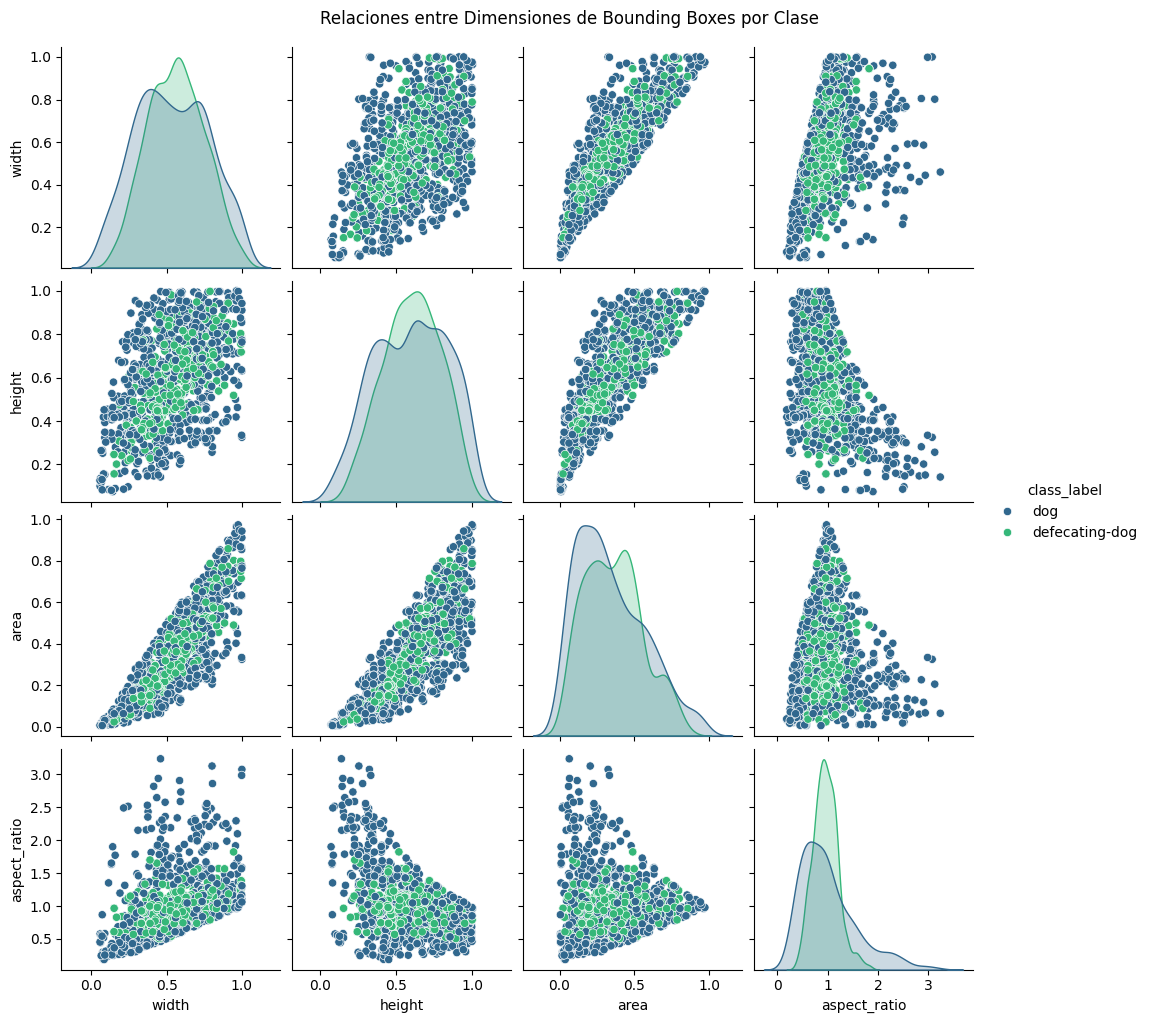


**Interpretación del Pairplot:**

El pairplot nos proporciona una visión integral de cómo interactúan las variables numéricas de las bounding boxes y si existen patrones diferenciados por cada clase:
-   **Diagonal (Distribuciones Unidimensionales):** Los gráficos en la diagonal muestran la distribución (mediante histogramas y estimación de densidad de kernel - KDE) de cada variable numérica individual (ancho, alto, área, relación de aspecto). El color indica la densidad de cada clase en esa distribución. Puedes ver si una clase tiende a tener objetos más grandes, más pequeños, más anchos, etc., que otras.
-   **Gráficos Fuera de la Diagonal (Relaciones Bivariadas):** Estos scatterplots muestran la relación entre cada par de variables. Cada punto representa una anotación y su color corresponde a su clase. Esto nos permite identificar:
    -   **Patrones de Agrupamiento:** ¿Las clases se agrupan en diferentes regiones del espacio bidimensional? Por ejemplo, si una clase se agrupa en la

In [ ]:
print("### 8. Análisis de Relaciones entre Variables (Pairplot)\n")

if not df_annotations.empty:
    # Columnas numéricas para el pairplot
    numerical_cols = ['width', 'height', 'area', 'aspect_ratio']

    # Asegurarse de que 'class_id' sea un tipo categórico para el hue
    df_annotations['class_id_str'] = df_annotations['class_id'].astype(str)
    if class_names:
        # Mapear class_id a nombres de clase si están disponibles
        df_annotations['class_label'] = df_annotations['class_id'].apply(lambda x: class_names[x] if x < len(class_names) else f'Unknown {x}')
        hue_col = 'class_label'
    else:
        hue_col = 'class_id_str'

    print("**Pairplot de Dimensiones de Bounding Boxes por Clase:**")
    print("Este gráfico muestra la relación de cada par de variables numéricas, con las distribuciones individuales en la diagonal, coloreadas por la clase.")

    # Generar el pairplot
    sns.pairplot(df_annotations, vars=numerical_cols, hue=hue_col, palette='viridis', diag_kind='kde')
    plt.suptitle('Relaciones entre Dimensiones de Bounding Boxes por Clase', y=1.02) # Ajustar el título
    plt.show()

    print("\n**Interpretación del Pairplot:**\n")
    print("El pairplot nos proporciona una visión integral de cómo interactúan las variables numéricas de las bounding boxes y si existen patrones diferenciados por cada clase:")
    print("-   **Diagonal (Distribuciones Unidimensionales):** Los gráficos en la diagonal muestran la distribución (mediante histogramas y estimación de densidad de kernel - KDE) de cada variable numérica individual (ancho, alto, área, relación de aspecto). El color indica la densidad de cada clase en esa distribución. Puedes ver si una clase tiende a tener objetos más grandes, más pequeños, más anchos, etc., que otras.")
    print("-   **Gráficos Fuera de la Diagonal (Relaciones Bivariadas):** Estos scatterplots muestran la relación entre cada par de variables. Cada punto representa una anotación y su color corresponde a su clase. Esto nos permite identificar:")
    print("    -   **Patrones de Agrupamiento:** ¿Las clases se agrupan en diferentes regiones del espacio bidimensional? Por ejemplo, si una clase se agrupa en la esquina inferior izquierda de un gráfico de 'width vs height', podría significar que esa clase se compone de objetos consistentemente más pequeños que las otras.")
    print("    -   **Tendencias Diferenciadas:** ¿La relación entre dos variables es diferente para cada clase? Por ejemplo, si para una clase, el ancho y el alto aumentan proporcionalmente, pero para otra, el ancho aumenta mucho más rápido que el alto.")
    print("    -   **Separabilidad:** Visualmente, ¿qué tan bien se separan las clases basándose en las combinaciones de estas dimensiones? Una buena separación sugiere que estas características son discriminativas para las clases.")

    print("\n**Ejemplos de lo que se puede buscar:**")
    print("-   Si el 'defecating-dog' se agrupa en una región específica (ej. áreas más pequeñas o relaciones de aspecto muy anchas) en comparación con 'dog', indica características morfológicas distintivas.")
    print("-   Observar si hay superposición significativa entre las clases en cualquier par de dimensiones, lo que indicaría que esas características no son suficientes por sí solas para diferenciarlas.")
    print("-   Identificar si alguna clase presenta un comportamiento de outliers más pronunciado en alguna dimensión bivariada.")
    df_annotations.drop(columns=['class_id_str', 'class_label'], errors='ignore', inplace=True)
else:
    print("No hay datos de anotaciones para realizar el análisis de relaciones entre variables.")

### 9. Identificación de Problemas para el Modelado

A partir del Análisis Exploratorio de Datos (EDA) realizado, es crucial identificar los desafíos y consideraciones principales que podrían afectar el rendimiento del modelo de detección de objetos. Estos puntos nos ayudarán a tomar decisiones informadas durante la fase de preparación de datos y entrenamiento del modelo. Las decisiones tomadas han sido especialmente explicadas en el documento informe.

In [ ]:
print("**Problemas y Desafíos Identificados para el Modelado:**\n")

# 1. Desbalance de Clases
if 'class_counts' in locals() and not class_counts.empty:
    min_class_count_val = class_counts.min()
    max_class_count_val = class_counts.max()
    balance_ratio_val = max_class_count_val / min_class_count_val if min_class_count_val > 0 else float('inf')

    print("**1. Desbalance de Clases:**")
    if balance_ratio_val > 2:
        print(f"   - **Problema Detectado:** Existe un **desbalance notable** entre las clases. La clase más frecuente tiene {max_class_count_val} instancias y la menos frecuente tiene {min_class_count_val} instancias (una proporción de {balance_ratio_val:.2f}:1). Esto podría llevar a que el modelo tenga un rendimiento subóptimo en la detección de la clase minoritaria.")
        print("   - **Impacto Potencial:** Menor precisión o recall para la clase minoritaria.")
        print("   - **Posibles Estrategias:** Oversampling, undersampling, data augmentation específico por clase, o pesos de clase durante el entrenamiento.")
    elif balance_ratio_val > 1.2:
        print(f"   - **Observación:** Hay un ligero desbalance entre las clases ({balance_ratio_val:.2f}:1). Es importante monitorear el rendimiento.")
    else:
        print("   - **Estado:** Las clases parecen estar relativamente bien balanceadas.")
else:
    print("**1. Desbalance de Clases:** No se pudieron calcular las estadísticas de balance de clases (posiblemente por falta de datos o `class_counts` no disponible).")
print("\n" + "-" * 50 + "\n")

# 2. Outliers / Ruido en los Datos (Dimensiones de Bounding Boxes)
if 'quality_report' in locals() and 'Registros Anómalos (Outliers IQR)' in quality_report:
    outlier_counts = quality_report['Registros Anómalos (Outliers IQR)']
    if outlier_counts:
        print("**2. Outliers / Ruido en los Datos (Dimensiones de Bounding Boxes):**")
        for col, count in outlier_counts.items():
            print(f"   - **Problema Detectado:** Se detectaron {count} outliers en la columna '{col}' mediante el método IQR. Estos valores extremos pueden representar anotaciones erróneas o casos reales pero muy atípicos (objetos muy pequeños, grandes o con relaciones de aspecto extremas).")
        print("   - **Impacto Potencial:** Si son errores, pueden sesgar el aprendizaje del modelo. Si son casos reales, pueden ser difíciles de aprender para el modelo y afectar la robustez.")
        print("   - **Posibles Estrategias:** Revisión manual de las anotaciones outliers, data augmentation para cubrir más variaciones, modelos más robustos o, en casos extremos, eliminación (con precaución).")
    else:
        print("**2. Outliers / Ruido en los Datos (Dimensiones de Bounding Boxes):** No se detectaron outliers significativos.")
else:
    print("**2. Outliers / Ruido en los Datos (Dimensiones de Bounding Boxes):** No se pudo acceder a la información de outliers (posiblemente `quality_report` no disponible).")
print("\n" + "-" * 50 + "\n")

# 3. Alta Correlación entre Variables (Dimensionalidad)
if 'correlation_matrix' in locals() and not correlation_matrix.empty:
    high_corr_pairs = []
    # Iterar sobre la matriz triangular superior para evitar duplicados y auto-correlaciones
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.8: # Umbral para 'alta correlación'
                high_corr_pairs.append((col1, col2, corr_value))

    if high_corr_pairs:
        print("**3. Alta Correlación entre Variables (Dimensionalidad):**")
        for col1, col2, corr_value in high_corr_pairs:
            print(f"   - **Observación:** Alta correlación (correlación={corr_value:.2f}) entre '{col1}' y '{col2}'. Como 'area' es una función de 'width' y 'height', estas correlaciones son esperadas.")
        print("   - **Impacto Potencial:** Para un modelo de detección de objetos como YOLOv8, estas dimensiones son típicamente usadas directamente. La alta correlación no es necesariamente un problema crítico, pero en otros modelos podría indicar redundancia.")
        print("   - **Posibles Estrategias:** Generalmente, para detección de objetos no requiere acción, pero en otros contextos podría implicar reducción de dimensionalidad o selección de características.")
    else:
        print("**3. Alta Correlación entre Variables (Dimensionalidad):** No se encontraron pares de variables con correlaciones extremadamente altas (abs > 0.8).")
else:
    print("**3. Alta Correlación entre Variables (Dimensionalidad):** No se pudo acceder a la matriz de correlación.")
print("\n" + "-" * 50 + "\n")

# 4. Valores Faltantes y Ruido (Consistencia de Anotaciones)
if 'quality_report' in locals() and 'Valores Faltantes' in quality_report and 'Valores Inconsistentes (Rango)' in quality_report:
    missing_vals = quality_report['Valores Faltantes']
    inconsistent_vals = quality_report['Valores Inconsistentes (Rango)']
    if not missing_vals and not inconsistent_vals:
        print("**4. Valores Faltantes y Ruido (Consistencia de Anotaciones):**")
        print("   - **Estado:** No se encontraron valores faltantes ni inconsistencias en el rango de las coordenadas o IDs de clase en el DataFrame procesado. Esto sugiere una buena calidad básica de las anotaciones.")
    else:
        print("**4. Valores Faltantes y Ruido (Consistencia de Anotaciones):**")
        if missing_vals:
            print(f"   - **Problema Detectado:** Se encontraron valores faltantes en las siguientes columnas: {', '.join(missing_vals.keys())}. Esto puede indicar anotaciones incompletas.")
        if inconsistent_vals:
            print(f"   - **Problema Detectado:** Se encontraron valores fuera de rango en las siguientes columnas: {', '.join(inconsistent_vals.keys())}. Estos son errores críticos en el formato YOLO.")
        print("   - **Impacto Potencial:** Errores o comportamientos inesperados del modelo, fallos en el entrenamiento.")
        print("   - **Posibles Estrategias:** Corrección manual de anotaciones o filtrado de datos erróneos.")
else:
    print("**4. Valores Faltantes y Ruido (Consistencia de Anotaciones):** No se pudo acceder a la información de valores faltantes o inconsistentes.")
print("\n" + "-" * 50 + "\n")

print("**Conclusión:**")
print("Los principales desafíos identificados son el **desbalance de clases** y la presencia de **outliers en las dimensiones de las bounding boxes**. La alta correlación entre ancho/alto/área es esperada y no crítica para YOLO. La ausencia de valores faltantes o inconsistencias de rango es un buen indicio de la calidad estructural del dataset. Se recomienda priorizar el tratamiento del desbalance de clases y la revisión/manejo de los outliers para mejorar la robustez y precisión del modelo.")

**Problemas y Desafíos Identificados para el Modelado:**

**1. Desbalance de Clases:**
   - **Estado:** Las clases parecen estar relativamente bien balanceadas.

--------------------------------------------------

**2. Outliers / Ruido en los Datos (Dimensiones de Bounding Boxes):** No se detectaron outliers significativos.

--------------------------------------------------

**3. Alta Correlación entre Variables (Dimensionalidad):**
   - **Observación:** Alta correlación (correlación=0.87) entre 'width' y 'area'. Como 'area' es una función de 'width' y 'height', estas correlaciones son esperadas.
   - **Observación:** Alta correlación (correlación=0.83) entre 'height' y 'area'. Como 'area' es una función de 'width' y 'height', estas correlaciones son esperadas.
   - **Impacto Potencial:** Para un modelo de detección de objetos como YOLOv8, estas dimensiones son típicamente usadas directamente. La alta correlación no es necesariamente un problema crítico, pero en otros modelos podría i

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if not df_annotations.empty:
    print("### 10. Análisis de Outliers por Clase\n")
    print("Este análisis cuantifica los outliers en 'area' y 'aspect_ratio' para cada clase, utilizando el método IQR (1.5x) calculado por separado para la distribución de cada clase.\n")

    outliers_per_class_report = {}
    numerical_cols_for_outliers = ['area', 'aspect_ratio'] # Enfocarse en columnas donde se notaron outliers previamente

    # Asegurarse de que class_names esté disponible; si no, usar IDs numéricos
    if 'class_names' not in locals() or class_names is None:
        # Si class_names no se cargó correctamente, intenta crearlo a partir de los IDs únicos
        unique_class_ids = df_annotations['class_id'].unique()
        class_names_map = {cid: f'Class {cid}' for cid in unique_class_ids}
    else:
        class_names_map = {i: name for i, name in enumerate(class_names)}

    for class_id_val in df_annotations['class_id'].unique():
        class_name_display = class_names_map.get(class_id_val, f'Unknown Class {class_id_val}')
        print(f"**Análisis de Outliers para la Clase: '{class_name_display}' (ID: {class_id_val})**")
        df_class = df_annotations[df_annotations['class_id'] == class_id_val].copy()

        class_outlier_counts = {}
        for col in numerical_cols_for_outliers:
            if col in df_class.columns:
                # Calcular IQR para la clase y columna actuales
                Q1 = df_class[col].quantile(0.25)
                Q3 = df_class[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR

                # Contar outliers para esta clase y columna
                col_data = df_class[col].dropna()
                outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)].count()
                class_outlier_counts[col] = outliers

        outliers_per_class_report[class_name_display] = class_outlier_counts

        if class_outlier_counts:
            for col, count in class_outlier_counts.items():
                print(f"- '{col}': {count} outliers detectados (usando límites IQR específicos para esta clase).")
        else:
            print("  No se detectaron outliers significativos para esta clase en las columnas analizadas.")
        print("-" * 30)

    print("\n**Resumen Consolidado de Outliers por Clase:**")
    outliers_summary_df = pd.DataFrame(outliers_per_class_report).fillna(0).astype(int)
    display(outliers_summary_df)

    print("\n**Interpretación:**")
    print("Este resumen te permite ver qué clase contribuye más a los outliers detectados en cada dimensión (área, relación de aspecto) cuando se consideran las distribuciones específicas de cada clase. Un número alto de outliers para una clase en particular podría indicar:")
    print("1.  **Variabilidad Extrema:** Los objetos de esa clase son inherentemente más diversos en tamaño o forma.")
    print("2.  **Errores de Anotación:** Posibles anotaciones incorrectas que deben ser revisadas manualmente.")
    print("3.  **Casos Raros/Extremos Reales:** Objetos de esa clase que son genuinamente inusuales y podrían requerir más datos de entrenamiento o estrategias específicas.")
    print("Considera revisar visualmente algunas de las imágenes con outliers para la clase con mayor conteo para entender mejor la naturaleza de estos valores.")

else:
    print("No hay datos de anotaciones para realizar el análisis de outliers por clase.")

### 10. Análisis de Outliers por Clase

Este análisis cuantifica los outliers en 'area' y 'aspect_ratio' para cada clase, utilizando el método IQR (1.5x) calculado por separado para la distribución de cada clase.

**Análisis de Outliers para la Clase: 'dog' (ID: 1)**
- 'area': 0 outliers detectados (usando límites IQR específicos para esta clase).
- 'aspect_ratio': 27 outliers detectados (usando límites IQR específicos para esta clase).
------------------------------
**Análisis de Outliers para la Clase: 'defecating-dog' (ID: 0)**
- 'area': 0 outliers detectados (usando límites IQR específicos para esta clase).
- 'aspect_ratio': 9 outliers detectados (usando límites IQR específicos para esta clase).
------------------------------

**Resumen Consolidado de Outliers por Clase:**


,dog,defecating-dog
area,0,0
aspect_ratio,27,9



**Interpretación:**
Este resumen te permite ver qué clase contribuye más a los outliers detectados en cada dimensión (área, relación de aspecto) cuando se consideran las distribuciones específicas de cada clase. Un número alto de outliers para una clase en particular podría indicar:
1.  **Variabilidad Extrema:** Los objetos de esa clase son inherentemente más diversos en tamaño o forma.
2.  **Errores de Anotación:** Posibles anotaciones incorrectas que deben ser revisadas manualmente.
3.  **Casos Raros/Extremos Reales:** Objetos de esa clase que son genuinamente inusuales y podrían requerir más datos de entrenamiento o estrategias específicas.
Considera revisar visualmente algunas de las imágenes con outliers para la clase con mayor conteo para entender mejor la naturaleza de estos valores.
